# utility-aware geometry filtering: full multi-seed scaling check

этот ноутбук делает полноценную проверку utility-based data selection для language modeling

Что здесь есть:
- doc-level split до chunking
- equal realized block budget
- sanity-check probe `human vs generated`
- usefulness proxy через gradient alignment / utility regressor
- subset-эксперименты на 10%, 30%, 70% и full
- curriculum-эксперименты
- несколько seed'ов
- итоговые scaling curves, zoomed learning curves и aggregate tables

Главная цель:
проверить, дает ли utility-aware geometry стабильный выигрыш над random и perplexity baselines на clean validation perplexity


In [1]:
# ===== 0. install / import =====
import os, sys, json, math, time, random, pickle, shutil, gc, warnings, hashlib, re
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings("ignore")

def text_hash(s: str, n=16):
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()[:n]

def ensure_pkg(pkg, import_name=None):
    import importlib, subprocess
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except Exception:
        print(f"installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg, imp in [
    ("datasets>=2.18.0", "datasets"),
    ("transformers>=4.44.0", "transformers"),
    ("tokenizers>=0.15.0", "tokenizers"),
    ("scikit-learn>=1.3.0", "sklearn"),
]:
    ensure_pkg(pkg, imp)

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn.functional as F
from torch import nn

from datasets import load_dataset
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import roc_auc_score, mean_squared_error

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    GPT2Config,
    GPT2LMHeadModel,
    get_cosine_schedule_with_warmup,
)


In [2]:
# ===== 1. config =====
@dataclass
class CFG:
    seed: int = 42
    seeds: Tuple[int, ...] = (11, 22, 33)

    # storage
    out_dir_name: str = "geom_utility_filtering_fullcheck_v1"
    resume_input_dataset: Optional[str] = None
    force_rebuild_raw: bool = False
    force_rebuild_mix: bool = False
    force_rebuild_features: bool = False
    force_rebuild_probe: bool = False
    force_rebuild_utility: bool = False
    force_rebuild_selections: bool = False
    force_rebuild_blocks: bool = False
    force_retrain: bool = False

    # raw collection
    wiki_target_chunks_total: int = 5200
    owt_target_chunks_total: int = 4200

    # split sizes
    train_total_chunks: int = 5400
    clean_val_total_chunks: int = 700
    stress_val_total_chunks: int = 500
    probe_total_chunks: int = 320

    # controlled train mixture
    train_mix: Tuple[float, float, float, float] = (0.34, 0.28, 0.14, 0.24)  # wiki / owt / noise / easydup
    clean_val_mix: Tuple[float, float] = (0.55, 0.45)  # wiki / owt
    stress_val_mix: Tuple[float, float, float] = (0.50, 0.35, 0.15)
    probe_mix: Tuple[float, float] = (0.50, 0.50)

    # raw / chunking
    doc_min_chars: int = 600
    doc_max_chars: int = 9000
    min_words_chunk: int = 70
    target_words_chunk: int = 110
    max_words_chunk: int = 150
    max_chunks_per_doc: int = 3

    # teacher / sanity-check verifier
    teacher_model_name: str = "distilgpt2"
    teacher_max_length: int = 128
    teacher_batch_size: int = 8
    probe_prompt_tokens: int = 40
    probe_gen_new_tokens: int = 48
    probe_min_total_tokens: int = 96
    probe_temperature: float = 0.9
    probe_top_p: float = 0.95
    min_probe_auc_to_trust: float = 0.62
    stop_if_probe_weak: bool = True
    saturation_random_trials: int = 128

    # utility proxy
    utility_label_sample_n: int = 768
    utility_holdout_frac: float = 0.25
    utility_anchor_blocks: int = 64
    utility_proxy_dim: int = 128
    utility_proxy_layers: int = 4
    utility_proxy_heads: int = 4
    utility_proxy_dropout: float = 0.1
    utility_proxy_warmup_steps: int = 80
    utility_proxy_warmup_examples: int = 360
    utility_proxy_batch_size: int = 8
    utility_proxy_lr: float = 4e-4
    utility_blend_novelty: float = 0.15
    utility_synthetic_cap_share: float = 0.08
    utility_prefilter_mul: float = 3.0
    utility_topk_eval_frac: float = 0.30

    # selection
    subset_fraction: float = 0.30
    subset_fractions: Tuple[float, ...] = (0.10, 0.30, 0.70)
    curriculum_fractions: Tuple[float, float, float] = (0.10, 0.30, 1.00)
    curriculum_phase_weights: Tuple[float, float, float] = (0.45, 0.30, 0.25)
    n_clusters: int = 32
    verified_prefilter_mul: float = 3.0
    verified_min_human_prob: float = 0.45
    target_ppl_quantile: float = 0.58
    synthetic_cap_share: float = 0.08
    run_verified_baseline: bool = False
    run_utility_mmr: bool = True

    # student LM
    student_block_size: int = 128
    student_stride: int = 64
    student_text_cap_tokens: int = 384
    student_model_dim: int = 256
    student_layers: int = 6
    student_heads: int = 4
    student_dropout: float = 0.1

    # training budget
    train_batch_size: int = 16
    eval_batch_size: int = 16
    max_steps: int = 560
    eval_every: int = 80
    warmup_steps: int = 40
    lr: float = 3e-4
    weight_decay: float = 0.01
    grad_clip: float = 1.0
    train_on_gpu_if_available: bool = True

    # which runs
    run_curriculum: bool = True
    run_full_baseline: bool = True
    run_smoke_test_first: bool = True
    run_curriculum_for_all_seeds: bool = True
    smoke_steps: int = 8

cfg = CFG()

SEED = cfg.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IN_KAGGLE = os.path.exists("/kaggle")
IN_COLAB = "google.colab" in sys.modules

if IN_KAGGLE:
    BASE_OUT_DIR = Path("/kaggle/working") / cfg.out_dir_name
elif IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        BASE_OUT_DIR = Path("/content/drive/MyDrive") / cfg.out_dir_name
    except Exception:
        BASE_OUT_DIR = Path("/content") / cfg.out_dir_name
else:
    BASE_OUT_DIR = Path.cwd() / cfg.out_dir_name

BASE_OUT_DIR.mkdir(parents=True, exist_ok=True)
for sub in ["cache", "plots", "artifacts", "experiments", "blocks"]:
    (BASE_OUT_DIR / sub).mkdir(parents=True, exist_ok=True)

if IN_KAGGLE and cfg.resume_input_dataset:
    src = Path("/kaggle/input") / cfg.resume_input_dataset
    if src.exists():
        print(f"copying previous artifacts from {src} -> {BASE_OUT_DIR}")
        for child in src.rglob("*"):
            rel = child.relative_to(src)
            dst = BASE_OUT_DIR / rel
            if child.is_dir():
                dst.mkdir(parents=True, exist_ok=True)
            elif not dst.exists():
                dst.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(child, dst)

DEVICE = "cuda" if (cfg.train_on_gpu_if_available and torch.cuda.is_available()) else "cpu"

def config_fingerprint(keys: List[str]) -> str:
    payload = {k: getattr(cfg, k) for k in keys}
    raw = json.dumps(payload, sort_keys=True, default=list)
    return text_hash(raw, n=12)

RAW_FINGERPRINT = config_fingerprint([
    "seed", "wiki_target_chunks_total", "owt_target_chunks_total", "doc_min_chars", "doc_max_chars",
    "min_words_chunk", "target_words_chunk", "max_words_chunk", "max_chunks_per_doc"
])
MIX_FINGERPRINT = config_fingerprint([
    "seed", "train_total_chunks", "clean_val_total_chunks", "stress_val_total_chunks", "probe_total_chunks",
    "train_mix", "clean_val_mix", "stress_val_mix", "probe_mix", "max_chunks_per_doc"
])
FEAT_FINGERPRINT = config_fingerprint([
    "seed", "teacher_model_name", "teacher_max_length", "train_total_chunks", "probe_total_chunks",
    "n_clusters", "verified_min_human_prob", "target_ppl_quantile"
])
PROBE_FINGERPRINT = config_fingerprint([
    "seed", "teacher_model_name", "teacher_max_length", "probe_prompt_tokens", "probe_gen_new_tokens",
    "probe_temperature", "probe_top_p", "probe_total_chunks"
])
BLOCK_FINGERPRINT = config_fingerprint([
    "seed", "student_block_size", "student_stride", "student_text_cap_tokens",
    "train_total_chunks", "clean_val_total_chunks", "stress_val_total_chunks"
])
UTILITY_FINGERPRINT = config_fingerprint([
    "seed", "subset_fraction", "utility_label_sample_n", "utility_holdout_frac", "utility_anchor_blocks",
    "utility_proxy_dim", "utility_proxy_layers", "utility_proxy_heads", "utility_proxy_dropout",
    "utility_proxy_warmup_steps", "utility_proxy_warmup_examples", "utility_proxy_batch_size",
    "utility_proxy_lr", "utility_blend_novelty", "student_block_size", "student_stride",
    "student_text_cap_tokens"
])
SEL_FINGERPRINT = config_fingerprint([
    "seed", "subset_fraction", "n_clusters", "verified_prefilter_mul", "verified_min_human_prob",
    "synthetic_cap_share", "target_ppl_quantile", "student_block_size", "student_stride",
    "utility_prefilter_mul", "utility_synthetic_cap_share", "utility_blend_novelty"
])

print("BASE_OUT_DIR =", BASE_OUT_DIR)
print("DEVICE =", DEVICE)
print("RAW_FINGERPRINT =", RAW_FINGERPRINT)
print("MIX_FINGERPRINT =", MIX_FINGERPRINT)
print("FEAT_FINGERPRINT =", FEAT_FINGERPRINT)
print("PROBE_FINGERPRINT =", PROBE_FINGERPRINT)
print("BLOCK_FINGERPRINT =", BLOCK_FINGERPRINT)
print("UTILITY_FINGERPRINT =", UTILITY_FINGERPRINT)
print("SEL_FINGERPRINT =", SEL_FINGERPRINT)


SEEDS = tuple(int(s) for s in cfg.seeds)
SUBSET_FRACTIONS = tuple(float(f) for f in cfg.subset_fractions)
FULL_FRACTION = 1.0
DIAGNOSTIC_SEED = int(SEEDS[0]) if len(SEEDS) > 0 else int(cfg.seed)

print("experiment seeds =", SEEDS)
print("subset fractions =", SUBSET_FRACTIONS, "full =", FULL_FRACTION)


BASE_OUT_DIR = /kaggle/working/geom_utility_filtering_fullcheck_v1
DEVICE = cuda
RAW_FINGERPRINT = e512fcf41dc7
MIX_FINGERPRINT = 7973edefc635
FEAT_FINGERPRINT = 7c8d3dd7df6a
PROBE_FINGERPRINT = 3c1c6552716c
BLOCK_FINGERPRINT = 247cd66b34f5
UTILITY_FINGERPRINT = b8b0a012ae3d
SEL_FINGERPRINT = 876ecdb0defd
experiment seeds = (11, 22, 33)
subset fractions = (0.1, 0.3, 0.7) full = 1.0


In [3]:

# ===== 2. io helpers =====
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def atomic_torch_save(obj, path):
    path = Path(path)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    tmp.replace(path)

def zscore(x):
    x = np.asarray(x, dtype=np.float64)
    std = x.std()
    if std < 1e-12:
        return np.zeros_like(x)
    return (x - x.mean()) / std

def residualize_against(x, control):
    x = np.asarray(x, dtype=np.float64)
    c = np.asarray(control, dtype=np.float64)
    A = np.vstack([np.ones_like(c), c]).T
    coef, *_ = np.linalg.lstsq(A, x, rcond=None)
    pred = A @ coef
    return x - pred

def rank_pct(x):
    x = pd.Series(np.asarray(x))
    return x.rank(method="average", pct=True).values.astype(np.float64)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [4]:
# ===== 3. text processing =====
import re

def normalize_text(text: str) -> str:
    text = text.replace("\x00", " ").replace("\u00a0", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_probably_bad_doc(text: str) -> bool:
    if not isinstance(text, str):
        return True
    t = normalize_text(text)
    if len(t) < cfg.doc_min_chars or len(t) > cfg.doc_max_chars:
        return True
    words = t.split()
    if len(words) < 120:
        return True
    alpha_ratio = sum(ch.isalpha() for ch in t) / max(1, len(t))
    if alpha_ratio < 0.55:
        return True
    return False

def clean_raw_doc(text: str, source: str) -> str:
    text = normalize_text(text)
    if source == "wiki":
        # remove obvious wiki headings and separators
        text = re.sub(r"(^|\n)\s*=+\s*[^=\n]{1,120}\s*=+\s*(?=\n|$)", " ", text)
        text = text.replace("@-@", "-")
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"\[[^\]]{0,100}\]", " ", text)
    text = re.sub(r"\{[^}]{0,100}\}", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def chunk_text(text: str) -> List[str]:
    words = text.split()
    chunks = []
    i = 0
    while i < len(words):
        span = words[i:i + cfg.target_words_chunk]
        if len(span) < cfg.min_words_chunk:
            break
        extra = 0
        while i + cfg.target_words_chunk + extra < len(words) and len(span) < cfg.max_words_chunk:
            w = words[i + cfg.target_words_chunk + extra]
            span.append(w)
            extra += 1
            if w.endswith((".", "!", "?")) and len(span) >= cfg.target_words_chunk:
                break
        chunk = " ".join(span).strip()
        if len(chunk.split()) >= cfg.min_words_chunk:
            chunks.append(chunk)
        i += max(cfg.min_words_chunk, cfg.target_words_chunk // 2)
    return chunks

def perturb_text(text: str, seed: int) -> str:
    rng = random.Random(seed)
    words = text.split()
    if len(words) < 30:
        return text

    ops = []

    def op_truncate(w):
        cut = max(20, int(len(w) * rng.uniform(0.35, 0.7)))
        return w[:cut]

    def op_duplicate(w):
        start = rng.randint(0, max(0, len(w) - 20))
        frag = w[start:start+20]
        pos = rng.randint(0, len(w))
        return w[:pos] + frag + frag + frag + w[pos:]

    def op_drop_punct(s):
        return re.sub(r"[.,;:!?\"'()\-]", " ", s)

    def op_lower(s):
        return s.lower()

    def op_listify(w):
        pieces = []
        step = max(8, len(w)//8)
        for i in range(0, len(w), step):
            pieces.append("- " + " ".join(w[i:i+step]))
        return " ".join(pieces)

    def op_local_shuffle(w):
        w = w[:]
        start = rng.randint(0, max(0, len(w)-25))
        end = min(len(w), start + rng.randint(10, 25))
        seg = w[start:end]
        rng.shuffle(seg)
        return w[:start] + seg + w[end:]

    choice = rng.choice(["truncate", "duplicate", "drop_punct", "listify", "shuffle"])
    if choice == "truncate":
        words = op_truncate(words)
    elif choice == "duplicate":
        words = op_duplicate(words)
    elif choice == "drop_punct":
        text = op_drop_punct(text)
        words = text.split()
    elif choice == "listify":
        words = op_listify(words).split()
    else:
        words = op_local_shuffle(words)

    if rng.random() < 0.6:
        words = [w.lower() for w in words]
    if rng.random() < 0.4:
        insert = ["###", "table", "header", "item", "item", "item"]
        pos = rng.randint(0, len(words))
        words = words[:pos] + insert + words[pos:]

    out = " ".join(words)
    out = re.sub(r"\s+", " ", out).strip()
    return out


In [5]:

# ===== 4. collect raw source documents with caching =====
raw_cache = BASE_OUT_DIR / "cache" / f"raw_docs_{RAW_FINGERPRINT}.pkl"

def collect_source_docs_until_chunks(dataset_name, split, source_name, target_chunks, seed, dataset_config=None):
    print(f"collecting {source_name} docs until ~{target_chunks} chunks...")
    if dataset_config is None:
        ds = load_dataset(dataset_name, split=split, streaming=True)
    else:
        ds = load_dataset(dataset_name, dataset_config, split=split, streaming=True)
    ds = ds.shuffle(seed=seed, buffer_size=20_000)

    rows = []
    seen_doc = set()
    seen_chunk = set()
    total_chunks = 0
    doc_counter = 0

    for row in tqdm(ds, total=None):
        text = row["text"]
        if not isinstance(text, str):
            continue
        if is_probably_bad_doc(text):
            continue
        text = clean_raw_doc(text, source_name)
        if is_probably_bad_doc(text):
            continue

        doc_hash = text_hash(text, n=20)
        if doc_hash in seen_doc:
            continue
        seen_doc.add(doc_hash)

        uniq_chunks = []
        for chunk in chunk_text(text):
            h = text_hash(chunk, n=20)
            if h in seen_chunk:
                continue
            seen_chunk.add(h)
            uniq_chunks.append(chunk)
            if len(uniq_chunks) >= cfg.max_chunks_per_doc:
                break

        if len(uniq_chunks) == 0:
            continue

        rows.append({
            "doc_id": f"{source_name}_doc_{doc_counter}",
            "source": source_name,
            "chunks": uniq_chunks,
            "n_chunks": int(len(uniq_chunks)),
            "doc_hash": doc_hash,
        })
        total_chunks += len(uniq_chunks)
        doc_counter += 1

        if total_chunks >= target_chunks:
            break

    docs_df = pd.DataFrame(rows)
    if len(docs_df) == 0:
        raise ValueError(f"no documents collected for {source_name}")
    return docs_df

if raw_cache.exists() and not cfg.force_rebuild_raw:
    raw = load_pickle(raw_cache)
    wiki_docs_df = raw["wiki_docs_df"]
    owt_docs_df = raw["owt_docs_df"]
else:
    wiki_docs_df = collect_source_docs_until_chunks(
        "Salesforce/wikitext", "train", "wiki", cfg.wiki_target_chunks_total, cfg.seed + 11,
        dataset_config="wikitext-103-raw-v1"
        )
    owt_docs_df = collect_source_docs_until_chunks(
        "Skylion007/openwebtext", "train", "owt", cfg.owt_target_chunks_total, cfg.seed + 29
    )
    save_pickle({"wiki_docs_df": wiki_docs_df, "owt_docs_df": owt_docs_df}, raw_cache)

print("wiki docs/chunks:", len(wiki_docs_df), int(wiki_docs_df["n_chunks"].sum()))
print("owt docs/chunks:", len(owt_docs_df), int(owt_docs_df["n_chunks"].sum()))
display(wiki_docs_df.head(2))
display(owt_docs_df.head(2))


collecting wiki docs until ~5200 chunks...


README.md: 0.00B [00:00, ?B/s]

0it [00:00, ?it/s]

collecting owt docs until ~4200 chunks...


README.md: 0.00B [00:00, ?B/s]

...

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

0it [00:00, ?it/s]

wiki docs/chunks: 2538 5200
owt docs/chunks: 1486 4201


,doc_id,source,chunks,n_chunks,doc_hash
0,wiki_doc_0,wiki,"[According to Demographia , Mogadishu has a po...",1,d0f548c3c1b84c0ad7b2
1,wiki_doc_1,wiki,[The first run of Super Science Stories was ed...,3,331cd6efe34614013726


,doc_id,source,chunks,n_chunks,doc_hash
0,owt_doc_0,owt,"[Well, what do we have here? It’s a Stargate: ...",1,dd8fd869663b2f94b395
1,owt_doc_1,owt,[A 16 year-old German boy was stabbed to death...,3,4476f43776895595892d


In [6]:

# ===== 5. build controlled train / validation / probe pools with doc-level split =====
mix_cache = BASE_OUT_DIR / "cache" / f"mixed_pool_{MIX_FINGERPRINT}.pkl"

def take_docs_by_chunk_budget(df_docs, target_chunks, seed):
    if target_chunks <= 0:
        return df_docs.iloc[:0].copy(), df_docs.copy()
    part = df_docs.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    csum = part["n_chunks"].cumsum().values
    k = int(np.searchsorted(csum, target_chunks, side="left")) + 1
    k = min(k, len(part))
    return part.iloc[:k].copy(), part.iloc[k:].copy()

def flatten_docs_to_chunks(df_docs, target_chunks, split_name):
    rows = []
    count = 0
    for _, row in df_docs.iterrows():
        for chunk in row["chunks"]:
            if count >= target_chunks:
                break
            rows.append({
                "text": chunk,
                "source": row["source"],
                "base_source": row["source"],
                "split": split_name,
                "doc_id": row["doc_id"],
                "doc_hash": row["doc_hash"],
            })
            count += 1
        if count >= target_chunks:
            break
    frame = pd.DataFrame(rows)
    if len(frame) != target_chunks:
        raise ValueError(f"requested {target_chunks} chunks for {split_name}, got {len(frame)}")
    return frame

def make_easydup_df(base_df, n, seed, split_name):
    rng = np.random.RandomState(seed)
    ids = rng.choice(len(base_df), size=n, replace=(n > len(base_df)))
    rows = []
    for i, idx in enumerate(ids):
        base_row = base_df.iloc[int(idx)]
        txt = normalize_text(base_row["text"])
        if (i % 3) == 0:
            txt = txt.replace(" ,", ",").replace(" .", ".")
        elif (i % 3) == 1:
            txt = txt.replace(" ; ", "; ").replace(" : ", ": ")
        else:
            txt = re.sub(r"\s+", " ", txt)
        rows.append({
            "text": txt,
            "source": "easydup",
            "base_source": base_row["source"],
            "split": split_name,
            "doc_id": f"easydup_from_{base_row['doc_id']}_{i}",
            "doc_hash": text_hash(txt, n=20),
        })
    return pd.DataFrame(rows)

def make_noise_df(base_df, n, seed, split_name):
    rng = np.random.RandomState(seed)
    ids = rng.choice(len(base_df), size=n, replace=(n > len(base_df)))
    rows = []
    for i, idx in enumerate(ids):
        base_row = base_df.iloc[int(idx)]
        noisy = perturb_text(base_row["text"], seed + i * 13 + 7)
        rows.append({
            "text": noisy,
            "source": "noise",
            "base_source": base_row["source"],
            "split": split_name,
            "doc_id": f"noise_from_{base_row['doc_id']}_{i}",
            "doc_hash": text_hash(noisy, n=20),
        })
    return pd.DataFrame(rows)

if mix_cache.exists() and not cfg.force_rebuild_mix:
    mix = load_pickle(mix_cache)
    train_pool = mix["train_pool"]
    clean_val_pool = mix["clean_val_pool"]
    stress_val_pool = mix["stress_val_pool"]
    probe_pool = mix["probe_pool"]
else:
    wiki_train_n = int(cfg.train_total_chunks * cfg.train_mix[0])
    owt_train_n  = int(cfg.train_total_chunks * cfg.train_mix[1])
    noi_train_n  = int(cfg.train_total_chunks * cfg.train_mix[2])
    dup_train_n  = cfg.train_total_chunks - wiki_train_n - owt_train_n - noi_train_n

    clean_wiki_val_n = int(cfg.clean_val_total_chunks * cfg.clean_val_mix[0])
    clean_owt_val_n  = cfg.clean_val_total_chunks - clean_wiki_val_n

    stress_wiki_val_n = int(cfg.stress_val_total_chunks * cfg.stress_val_mix[0])
    stress_owt_val_n  = int(cfg.stress_val_total_chunks * cfg.stress_val_mix[1])
    stress_noi_val_n  = cfg.stress_val_total_chunks - stress_wiki_val_n - stress_owt_val_n

    probe_wiki_n = int(cfg.probe_total_chunks * cfg.probe_mix[0])
    probe_owt_n = cfg.probe_total_chunks - probe_wiki_n

    wiki_need = wiki_train_n + clean_wiki_val_n + stress_wiki_val_n + probe_wiki_n
    owt_need  = owt_train_n  + clean_owt_val_n  + stress_owt_val_n  + probe_owt_n

    if int(wiki_docs_df["n_chunks"].sum()) < wiki_need:
        raise ValueError(f"not enough wiki chunks collected: need {wiki_need}, have {int(wiki_docs_df['n_chunks'].sum())}")
    if int(owt_docs_df["n_chunks"].sum()) < owt_need:
        raise ValueError(f"not enough owt chunks collected: need {owt_need}, have {int(owt_docs_df['n_chunks'].sum())}")

    wiki_train_docs, wiki_rest = take_docs_by_chunk_budget(wiki_docs_df, wiki_train_n, cfg.seed + 1)
    wiki_clean_val_docs, wiki_rest = take_docs_by_chunk_budget(wiki_rest, clean_wiki_val_n, cfg.seed + 2)
    wiki_stress_docs, wiki_rest = take_docs_by_chunk_budget(wiki_rest, stress_wiki_val_n, cfg.seed + 3)
    wiki_probe_docs, _ = take_docs_by_chunk_budget(wiki_rest, probe_wiki_n, cfg.seed + 4)

    owt_train_docs, owt_rest = take_docs_by_chunk_budget(owt_docs_df, owt_train_n, cfg.seed + 5)
    owt_clean_val_docs, owt_rest = take_docs_by_chunk_budget(owt_rest, clean_owt_val_n, cfg.seed + 6)
    owt_stress_docs, owt_rest = take_docs_by_chunk_budget(owt_rest, stress_owt_val_n, cfg.seed + 7)
    owt_probe_docs, _ = take_docs_by_chunk_budget(owt_rest, probe_owt_n, cfg.seed + 8)

    wiki_train = flatten_docs_to_chunks(wiki_train_docs, wiki_train_n, "train")
    wiki_clean_val = flatten_docs_to_chunks(wiki_clean_val_docs, clean_wiki_val_n, "clean_val")
    wiki_stress_val = flatten_docs_to_chunks(wiki_stress_docs, stress_wiki_val_n, "stress_val")
    wiki_probe = flatten_docs_to_chunks(wiki_probe_docs, probe_wiki_n, "probe")

    owt_train = flatten_docs_to_chunks(owt_train_docs, owt_train_n, "train")
    owt_clean_val = flatten_docs_to_chunks(owt_clean_val_docs, clean_owt_val_n, "clean_val")
    owt_stress_val = flatten_docs_to_chunks(owt_stress_docs, stress_owt_val_n, "stress_val")
    owt_probe = flatten_docs_to_chunks(owt_probe_docs, probe_owt_n, "probe")

    clean_train = pd.concat([wiki_train, owt_train], ignore_index=True)
    noise_train = make_noise_df(clean_train, noi_train_n, cfg.seed + 300, "train")
    easydup_train = make_easydup_df(clean_train, dup_train_n, cfg.seed + 350, "train")
    train_pool = pd.concat([clean_train, noise_train, easydup_train], ignore_index=True).sample(
        frac=1.0, random_state=cfg.seed
    ).reset_index(drop=True)

    clean_val_pool = pd.concat([wiki_clean_val, owt_clean_val], ignore_index=True).sample(
        frac=1.0, random_state=cfg.seed + 10
    ).reset_index(drop=True)

    stress_clean = pd.concat([wiki_stress_val, owt_stress_val], ignore_index=True)
    stress_noise = make_noise_df(stress_clean, stress_noi_val_n, cfg.seed + 500, "stress_val")
    stress_val_pool = pd.concat([stress_clean, stress_noise], ignore_index=True).sample(
        frac=1.0, random_state=cfg.seed + 11
    ).reset_index(drop=True)

    probe_pool = pd.concat([wiki_probe, owt_probe], ignore_index=True).sample(
        frac=1.0, random_state=cfg.seed + 12
    ).reset_index(drop=True)

    train_pool["row_id"] = np.arange(len(train_pool))
    clean_val_pool["row_id"] = np.arange(len(clean_val_pool))
    stress_val_pool["row_id"] = np.arange(len(stress_val_pool))
    probe_pool["row_id"] = np.arange(len(probe_pool))

    train_doc_hashes = set(train_pool[~train_pool["source"].isin(["noise", "easydup"])]["doc_hash"].tolist())
    clean_val_hashes = set(clean_val_pool["doc_hash"].tolist())
    stress_clean_hashes = set(stress_clean["doc_hash"].tolist())
    probe_hashes = set(probe_pool["doc_hash"].tolist())

    assert len(train_doc_hashes & clean_val_hashes) == 0
    assert len(train_doc_hashes & stress_clean_hashes) == 0
    assert len(clean_val_hashes & stress_clean_hashes) == 0
    assert len(train_doc_hashes & probe_hashes) == 0
    assert len(clean_val_hashes & probe_hashes) == 0
    assert len(stress_clean_hashes & probe_hashes) == 0

    save_pickle(
        {
            "train_pool": train_pool,
            "clean_val_pool": clean_val_pool,
            "stress_val_pool": stress_val_pool,
            "probe_pool": probe_pool,
        },
        mix_cache,
    )

for frame in [train_pool, clean_val_pool, stress_val_pool, probe_pool]:
    frame["n_words"] = frame["text"].str.split().str.len()

train_doc_hashes = set(train_pool[~train_pool["source"].isin(["noise", "easydup"])]["doc_hash"].tolist())
clean_val_hashes = set(clean_val_pool["doc_hash"].tolist())
stress_clean_hashes = set(stress_val_pool[stress_val_pool["source"] != "noise"]["doc_hash"].tolist())
probe_hashes = set(probe_pool["doc_hash"].tolist())
print("doc leakage train-clean:", len(train_doc_hashes & clean_val_hashes))
print("doc leakage train-stress:", len(train_doc_hashes & stress_clean_hashes))
print("doc leakage clean-stress:", len(clean_val_hashes & stress_clean_hashes))
print("doc leakage train-probe:", len(train_doc_hashes & probe_hashes))

print("train_pool:", train_pool.shape, train_pool["source"].value_counts().to_dict())
print("clean_val_pool:", clean_val_pool.shape, clean_val_pool["source"].value_counts().to_dict())
print("stress_val_pool:", stress_val_pool.shape, stress_val_pool["source"].value_counts().to_dict())
print("probe_pool:", probe_pool.shape, probe_pool["source"].value_counts().to_dict())
display(train_pool.head(3))


doc leakage train-clean: 0
doc leakage train-stress: 0
doc leakage clean-stress: 0
doc leakage train-probe: 0
train_pool: (5400, 8) {'wiki': 1836, 'owt': 1512, 'easydup': 1296, 'noise': 756}
clean_val_pool: (700, 8) {'wiki': 385, 'owt': 315}
stress_val_pool: (500, 8) {'wiki': 250, 'owt': 175, 'noise': 75}
probe_pool: (320, 8) {'wiki': 160, 'owt': 160}


,text,source,base_source,split,doc_id,doc_hash,row_id,n_words
0,Indy Star reports that same valet was later ar...,owt,owt,train,owt_doc_778,b5b29f5828ddaf6becf2,0,143
1,made training cruises to Europe with midshipme...,wiki,wiki,train,wiki_doc_286,6acdbaecab0e7c0b0993,1,104
2,NEW DELHI: In the run-up to PM Narendra Modi’s...,owt,owt,train,owt_doc_1418,f99289114efa49f537f5,2,150


In [7]:
# ===== 6. teacher tokenizer + model =====
teacher_cache_dir = BASE_OUT_DIR / "artifacts" / "teacher_model"
teacher_tok_cache_dir = BASE_OUT_DIR / "artifacts" / "teacher_tokenizer"

teacher_tokenizer = AutoTokenizer.from_pretrained(cfg.teacher_model_name, cache_dir=str(teacher_tok_cache_dir))
if teacher_tokenizer.pad_token is None:
    teacher_tokenizer.pad_token = teacher_tokenizer.eos_token

teacher_model = AutoModelForCausalLM.from_pretrained(
    cfg.teacher_model_name,
    cache_dir=str(teacher_cache_dir),
).to(DEVICE)
teacher_model.eval()

print("teacher ready:", cfg.teacher_model_name)


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

teacher ready: distilgpt2


In [8]:

# ===== 6. geometry features with caching =====
def effective_rank(hidden_states: np.ndarray) -> float:
    X = hidden_states.astype(np.float64)
    X = X - X.mean(axis=0, keepdims=True)
    try:
        s = np.linalg.svd(X, compute_uv=False)
    except np.linalg.LinAlgError:
        return 1.0
    s2 = s**2
    total = s2.sum()
    if total <= 0:
        return 1.0
    p = s2 / total
    p = p[p > 1e-12]
    return float(np.exp(-(p * np.log(p)).sum()))

def mev_ratio(hidden_states: np.ndarray) -> float:
    X = hidden_states.astype(np.float64)
    X = X - X.mean(axis=0, keepdims=True)
    try:
        s = np.linalg.svd(X, compute_uv=False)
    except np.linalg.LinAlgError:
        return 1.0
    if len(s) == 0:
        return 1.0
    denom = np.maximum((s**2).sum(), 1e-12)
    return float((s[0]**2) / denom)

def token_lid_mle(hidden_states: np.ndarray, k: int = 5) -> float:
    X = hidden_states.astype(np.float64)
    X = X - X.mean(axis=0, keepdims=True)
    n = X.shape[0]
    if n <= max(k + 1, 8):
        return 1.0
    # pairwise distances
    sq = np.sum(X * X, axis=1, keepdims=True)
    D2 = np.maximum(sq + sq.T - 2.0 * (X @ X.T), 0.0)
    D = np.sqrt(D2 + 1e-12)
    np.fill_diagonal(D, np.inf)
    idx = np.argpartition(D, kth=min(k, n - 2), axis=1)[:, :k]
    dknn = np.take_along_axis(D, idx, axis=1)
    dknn = np.sort(dknn, axis=1)
    rk = dknn[:, -1:]
    valid = np.isfinite(rk).ravel() & (rk.ravel() > 1e-12)
    if valid.sum() == 0:
        return 1.0
    vals = np.log(np.clip(dknn[valid] / rk[valid], 1e-12, None))
    denom = -np.mean(vals, axis=1)
    denom = denom[np.isfinite(denom) & (denom > 1e-12)]
    if len(denom) == 0:
        return 1.0
    lids = 1.0 / denom
    lids = lids[np.isfinite(lids)]
    if len(lids) == 0:
        return 1.0
    return float(np.median(lids))

@torch.no_grad()
def extract_features_for_texts(texts: List[str], batch_size: int, desc: str):
    rows = []
    for start in tqdm(range(0, len(texts), batch_size), desc=desc):
        batch = texts[start:start+batch_size]
        enc = teacher_tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=cfg.teacher_max_length,
        )
        input_ids = enc["input_ids"].to(DEVICE)
        attn = enc["attention_mask"].to(DEVICE)

        out = teacher_model(
            input_ids=input_ids,
            attention_mask=attn,
            output_hidden_states=True,
        )
        losses = F.cross_entropy(
            out.logits[:, :-1, :].reshape(-1, out.logits.size(-1)),
            input_ids[:, 1:].reshape(-1),
            reduction="none",
        ).reshape(input_ids.size(0), -1)

        token_mask = attn[:, 1:].float()
        mean_losses = (losses * token_mask).sum(dim=1) / token_mask.sum(dim=1).clamp_min(1.0)
        ppls = torch.exp(mean_losses).detach().cpu().numpy()

        hs = out.hidden_states[-1].detach().cpu().numpy()
        attn_np = attn.detach().cpu().numpy()

        for j in range(len(batch)):
            m = attn_np[j].astype(bool)
            tok_h = hs[j][m]
            pooled = tok_h.mean(axis=0)
            er = effective_rank(tok_h)
            mev = mev_ratio(tok_h)
            lid = token_lid_mle(tok_h, k=5)
            rows.append({
                "reference_ppl": float(ppls[j]),
                "teacher_len": int(m.sum()),
                "effective_rank": er,
                "mev_ratio": mev,
                "token_lid": lid,
                "teacher_emb": pooled.astype(np.float32),
            })
    return rows

def attach_feature_cache(frame: pd.DataFrame, cache_name: str) -> pd.DataFrame:
    cache_path = BASE_OUT_DIR / "cache" / f"{cache_name}_{FEAT_FINGERPRINT}.pkl"
    if cache_path.exists() and not cfg.force_rebuild_features:
        feats = load_pickle(cache_path)
        if len(feats) != len(frame):
            raise ValueError(f"feature cache length mismatch for {cache_name}: {len(feats)} vs {len(frame)}")
    else:
        feats = extract_features_for_texts(frame["text"].tolist(), cfg.teacher_batch_size, desc=f"teacher_features:{cache_name}")
        save_pickle(feats, cache_path)

    out = frame.copy()
    for k in ["reference_ppl", "teacher_len", "effective_rank", "mev_ratio", "token_lid"]:
        out[k] = [row[k] for row in feats]
    out["teacher_emb"] = [row["teacher_emb"] for row in feats]

    out["er_resid_len"] = residualize_against(out["effective_rank"].values, out["teacher_len"].values)
    out["lid_resid_len"] = residualize_against(out["token_lid"].values, out["teacher_len"].values)
    out["mev_resid_len"] = residualize_against(out["mev_ratio"].values, out["teacher_len"].values)

    # raw geometry proxy, still unsupervised
    out["geom_quality_raw"] = (
        0.45 * zscore(out["er_resid_len"].values) +
        0.35 * zscore(out["lid_resid_len"].values) -
        0.20 * zscore(out["mev_resid_len"].values)
    )
    return out

train_pool = attach_feature_cache(train_pool, "train_pool")
probe_pool = attach_feature_cache(probe_pool, "probe_pool")
print("train feature matrix:", np.stack(train_pool["teacher_emb"].values).shape)
display(train_pool[["source", "reference_ppl", "teacher_len", "effective_rank", "token_lid", "mev_ratio", "geom_quality_raw"]].head())


teacher_features:train_pool:   0%|          | 0/675 [00:00<?, ?it/s]

teacher_features:probe_pool:   0%|          | 0/40 [00:00<?, ?it/s]

train feature matrix: (5400, 768)


,source,reference_ppl,teacher_len,effective_rank,token_lid,mev_ratio,geom_quality_raw
0,owt,54.736408,128,2.559245,9.887607,0.791515,-1.046942
1,wiki,39.989922,113,3.245735,10.367644,0.763434,-0.580411
2,owt,32.092716,128,4.553344,9.295602,0.656437,-0.152636
3,owt,31.679420,128,2.547316,11.216345,0.827411,-0.743152
4,owt,34.569386,128,3.220514,11.648375,0.771205,-0.228630


In [9]:

# ===== 7. clustering + redundancy proxy =====
cluster_cache = BASE_OUT_DIR / "cache" / f"cluster_assignments_{FEAT_FINGERPRINT}.pkl"

if cluster_cache.exists() and not cfg.force_rebuild_features:
    clu = load_pickle(cluster_cache)
    if len(clu["cluster_id"]) != len(train_pool):
        raise ValueError(f"cluster cache length mismatch: {len(clu['cluster_id'])} vs {len(train_pool)}. Set force_rebuild_features=True.")
    train_pool["cluster_id"] = clu["cluster_id"]
else:
    scaler = StandardScaler()
    X = scaler.fit_transform(np.stack(train_pool["teacher_emb"].values))
    km = MiniBatchKMeans(n_clusters=cfg.n_clusters, random_state=cfg.seed, batch_size=256, n_init=10)
    cluster_id = km.fit_predict(X)
    train_pool["cluster_id"] = cluster_id
    save_pickle({"cluster_id": cluster_id}, cluster_cache)

def attach_redundancy_proxy(df: pd.DataFrame, cluster_col: str = "cluster_id") -> pd.DataFrame:
    out = df.copy()
    embs = np.stack(out["teacher_emb"].values).astype(np.float32)
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    embs = embs / np.clip(norms, 1e-8, None)
    nn_sim = np.zeros(len(out), dtype=np.float32)

    for cid, idx in out.groupby(cluster_col).groups.items():
        idx = np.asarray(list(idx), dtype=np.int64)
        sub = embs[idx]
        sims = sub @ sub.T
        np.fill_diagonal(sims, -1.0)
        nn_sim[idx] = sims.max(axis=1)

    out["nn_cosine_sim"] = nn_sim
    out["novelty_score"] = -zscore(out["nn_cosine_sim"].values)
    return out

train_pool = attach_redundancy_proxy(train_pool)
display(train_pool["cluster_id"].value_counts().head())
display(train_pool[["source", "cluster_id", "nn_cosine_sim", "novelty_score"]].head())


cluster_id
27    476
26    302
5     283
21    280
9     272
Name: count, dtype: int64

,source,cluster_id,nn_cosine_sim,novelty_score
0,owt,12,0.999309,0.340257
1,wiki,20,1.000001,-0.555514
2,owt,4,1.000000,-0.554665
3,owt,2,1.000000,-0.554896
4,owt,12,1.000000,-0.554742


probe_pairs:   0%|          | 0/320 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


teacher_features:probe_pairs:   0%|          | 0/66 [00:00<?, ?it/s]

{
  "n_probe_examples": 528,
  "n_probe_pairs": 264,
  "overall_test_auc": 0.9792187499999999,
  "by_source_auc": {
    "owt": 0.9763313609467456,
    "wiki": 0.992266508030934
  },
  "direction_report": {
    "human_er_minus_gen": 0.7478892446801697,
    "human_lid_minus_gen": 1.5242760389640235,
    "human_mev_minus_gen": -0.024649617605806418
  }
}


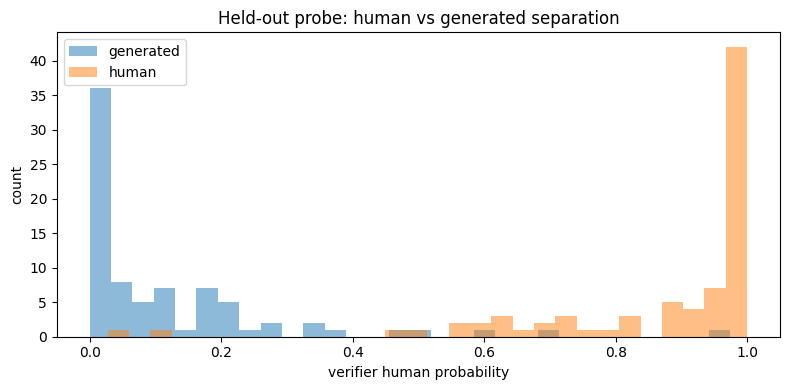

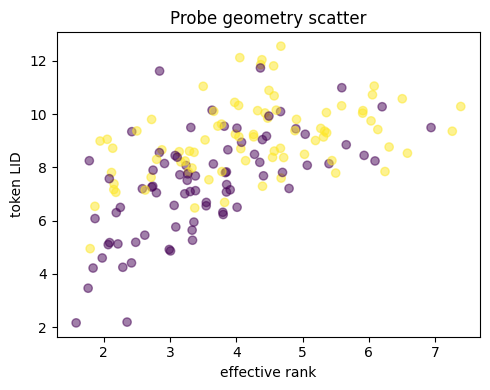

train human_prob summary


,source,human_prob,human_logit,verified_score,ppl_mid_pref,nn_cosine_sim
0,owt,1.0,13.81551,0.260082,-0.140741,0.999309
1,wiki,1.0,13.81551,-0.152599,-0.321574,1.000001
2,owt,1.0,13.81551,-0.286113,-0.425093,1.000000
3,owt,1.0,13.81551,-0.292616,-0.430093,1.000000
4,owt,1.0,13.81551,-0.241408,-0.390463,1.000000


In [10]:

# ===== 8. human vs generated verifier on held-out probe =====
probe_cache = BASE_OUT_DIR / "cache" / f"probe_pairs_{PROBE_FINGERPRINT}.pkl"

def make_probe_pairs(probe_df: pd.DataFrame):
    rows = []
    eos_id = teacher_tokenizer.eos_token_id
    for i, row in tqdm(probe_df.iterrows(), total=len(probe_df), desc="probe_pairs"):
        ids = teacher_tokenizer.encode(row["text"], add_special_tokens=False, truncation=True, max_length=cfg.teacher_max_length)
        if len(ids) < cfg.probe_min_total_tokens:
            continue
        prompt_ids = ids[:cfg.probe_prompt_tokens]
        human_ids = ids[cfg.probe_prompt_tokens:cfg.probe_prompt_tokens + cfg.probe_gen_new_tokens]
        if len(human_ids) < max(24, cfg.probe_gen_new_tokens // 2):
            continue

        prompt = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
        gen = teacher_model.generate(
            prompt,
            do_sample=True,
            temperature=cfg.probe_temperature,
            top_p=cfg.probe_top_p,
            max_new_tokens=len(human_ids),
            pad_token_id=eos_id,
            eos_token_id=eos_id,
        )
        gen_new_ids = gen[0].tolist()[len(prompt_ids):len(prompt_ids) + len(human_ids)]
        human_text = teacher_tokenizer.decode(human_ids, skip_special_tokens=True)
        gen_text = teacher_tokenizer.decode(gen_new_ids, skip_special_tokens=True)

        if len(human_text.strip()) < 40 or len(gen_text.strip()) < 40:
            continue

        pair_id = f"pair_{len(rows)//2}"
        rows.append({
            "pair_id": pair_id,
            "label": 1,
            "label_name": "human",
            "source": row["source"],
            "text": human_text,
        })
        rows.append({
            "pair_id": pair_id,
            "label": 0,
            "label_name": "generated",
            "source": row["source"],
            "text": gen_text,
        })
    probe_pairs = pd.DataFrame(rows)
    if len(probe_pairs) == 0:
        raise ValueError("probe pair generation failed")
    return probe_pairs

if probe_cache.exists() and not cfg.force_rebuild_probe:
    probe_pairs = load_pickle(probe_cache)
else:
    probe_pairs = make_probe_pairs(probe_pool)
    save_pickle(probe_pairs, probe_cache)

probe_pairs = attach_feature_cache(probe_pairs, "probe_pairs")

feat_cols = ["effective_rank", "token_lid", "mev_ratio", "reference_ppl", "teacher_len"]
X = probe_pairs[feat_cols].copy()
X["log_ppl"] = np.log(np.clip(X["reference_ppl"].values, 1e-6, None))
X = X.drop(columns=["reference_ppl"])
y = probe_pairs["label"].values.astype(int)

# split by pair_id so paired human/generated examples don't leak
pair_ids = probe_pairs["pair_id"].drop_duplicates().sample(frac=1.0, random_state=cfg.seed).tolist()
cut = int(len(pair_ids) * 0.7)
train_pair_ids = set(pair_ids[:cut])
test_pair_ids = set(pair_ids[cut:])

tr_mask = probe_pairs["pair_id"].isin(train_pair_ids).values
te_mask = probe_pairs["pair_id"].isin(test_pair_ids).values

scaler_probe = StandardScaler()
X_tr = scaler_probe.fit_transform(X[tr_mask])
X_te = scaler_probe.transform(X[te_mask])

clf_probe = LogisticRegression(max_iter=2000, random_state=cfg.seed)
clf_probe.fit(X_tr, y[tr_mask])

probe_pairs["human_prob"] = np.nan
probe_pairs.loc[tr_mask, "human_prob"] = clf_probe.predict_proba(X_tr)[:, 1]
probe_pairs.loc[te_mask, "human_prob"] = clf_probe.predict_proba(X_te)[:, 1]

overall_auc = roc_auc_score(y[te_mask], probe_pairs.loc[te_mask, "human_prob"].values)
by_source_auc = {}
for src in sorted(probe_pairs["source"].unique()):
    m = te_mask & (probe_pairs["source"].values == src)
    if m.sum() >= 8 and len(np.unique(y[m])) == 2:
        by_source_auc[src] = float(roc_auc_score(y[m], probe_pairs.loc[m, "human_prob"].values))

direction_report = {
    "human_er_minus_gen": float(
        probe_pairs[probe_pairs["label"] == 1]["effective_rank"].mean() -
        probe_pairs[probe_pairs["label"] == 0]["effective_rank"].mean()
    ),
    "human_lid_minus_gen": float(
        probe_pairs[probe_pairs["label"] == 1]["token_lid"].mean() -
        probe_pairs[probe_pairs["label"] == 0]["token_lid"].mean()
    ),
    "human_mev_minus_gen": float(
        probe_pairs[probe_pairs["label"] == 1]["mev_ratio"].mean() -
        probe_pairs[probe_pairs["label"] == 0]["mev_ratio"].mean()
    ),
}

probe_summary = {
    "n_probe_examples": int(len(probe_pairs)),
    "n_probe_pairs": int(probe_pairs["pair_id"].nunique()),
    "overall_test_auc": float(overall_auc),
    "by_source_auc": by_source_auc,
    "direction_report": direction_report,
}
save_json(probe_summary, BASE_OUT_DIR / "probe_verifier_summary.json")

print(json.dumps(probe_summary, indent=2))

plt.figure(figsize=(8, 4))
for lab, grp in probe_pairs[te_mask].groupby("label_name"):
    plt.hist(grp["human_prob"], bins=30, alpha=0.5, label=lab)
plt.xlabel("verifier human probability")
plt.ylabel("count")
plt.title("Held-out probe: human vs generated separation")
plt.legend()
plt.tight_layout()
plt.savefig(BASE_OUT_DIR / "plots" / "probe_human_prob_hist.png", dpi=150)
plt.show()

plt.figure(figsize=(5, 4))
plt.scatter(
    probe_pairs[te_mask]["effective_rank"],
    probe_pairs[te_mask]["token_lid"],
    c=probe_pairs[te_mask]["label"].values,
    alpha=0.5,
)
plt.xlabel("effective rank")
plt.ylabel("token LID")
plt.title("Probe geometry scatter")
plt.tight_layout()
plt.savefig(BASE_OUT_DIR / "plots" / "probe_geom_scatter.png", dpi=150)
plt.show()

# fit final verifier on all probe pairs
scaler_probe_final = StandardScaler()
X_all = scaler_probe_final.fit_transform(X)
clf_probe_final = LogisticRegression(max_iter=3000, random_state=cfg.seed)
clf_probe_final.fit(X_all, y)

def apply_probe_verifier(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    Z = out[feat_cols].copy()
    Z["log_ppl"] = np.log(np.clip(Z["reference_ppl"].values, 1e-6, None))
    Z = Z.drop(columns=["reference_ppl"])
    zz = scaler_probe_final.transform(Z)
    prob = clf_probe_final.predict_proba(zz)[:, 1]
    out["human_prob"] = prob
    out["human_logit"] = np.log(np.clip(prob, 1e-6, 1 - 1e-6) / np.clip(1 - prob, 1e-6, 1 - 1e-6))
    return out

train_pool = apply_probe_verifier(train_pool)

ppl_pct = rank_pct(train_pool["reference_ppl"].values)
train_pool["ppl_mid_pref"] = -np.abs(ppl_pct - cfg.target_ppl_quantile)
train_pool["verified_score"] = (
    0.60 * zscore(train_pool["human_logit"].values) +
    0.20 * zscore(train_pool["ppl_mid_pref"].values) +
    0.20 * zscore(train_pool["novelty_score"].values)
)

print("train human_prob summary")
display(train_pool[["source", "human_prob", "human_logit", "verified_score", "ppl_mid_pref", "nn_cosine_sim"]].head())

if overall_auc < cfg.min_probe_auc_to_trust:
    msg = f"held-out probe AUC={overall_auc:.3f} < trust threshold {cfg.min_probe_auc_to_trust:.3f}"
    print("WARNING:", msg)
    if cfg.stop_if_probe_weak:
        raise RuntimeError(msg)


In [11]:

# ===== 9. student tokenizer, block estimates, and validation blocks =====
student_tok_cache_dir = BASE_OUT_DIR / "artifacts" / "student_tokenizer"
student_tokenizer = AutoTokenizer.from_pretrained("gpt2", cache_dir=str(student_tok_cache_dir))
if student_tokenizer.pad_token is None:
    student_tokenizer.pad_token = student_tokenizer.eos_token

student_stats_cache = BASE_OUT_DIR / "cache" / f"student_stats_train_{BLOCK_FINGERPRINT}.pkl"

def estimate_block_count(token_len: int, block_size: int, stride: int) -> int:
    if token_len < block_size + 1:
        return 0
    return 1 + (token_len - (block_size + 1)) // stride

def build_student_stats_for_texts(texts: List[str], batch_size: int = 64):
    rows = []
    for start in tqdm(range(0, len(texts), batch_size), desc="student_stats"):
        batch = texts[start:start+batch_size]
        enc = student_tokenizer(
            batch,
            add_special_tokens=False,
            truncation=True,
            max_length=cfg.student_text_cap_tokens,
            padding=False,
        )
        for ids in enc["input_ids"]:
            L = int(len(ids))
            rows.append({
                "student_len_capped": L,
                "block_estimate": int(estimate_block_count(L, cfg.student_block_size, cfg.student_stride)),
            })
    return rows

if student_stats_cache.exists() and not cfg.force_rebuild_blocks:
    train_student_stats = load_pickle(student_stats_cache)
    if len(train_student_stats) != len(train_pool):
        raise ValueError(f"student stats cache length mismatch: {len(train_student_stats)} vs {len(train_pool)}. Set force_rebuild_blocks=True.")
else:
    train_student_stats = build_student_stats_for_texts(train_pool["text"].tolist())
    save_pickle(train_student_stats, student_stats_cache)

train_pool["student_len_capped"] = [row["student_len_capped"] for row in train_student_stats]
train_pool["block_estimate"] = [row["block_estimate"] for row in train_student_stats]

def blocks_cache_path(name):
    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    return BASE_OUT_DIR / "blocks" / f"{safe_name}_{BLOCK_FINGERPRINT}.npz"

def text_ids(text):
    return student_tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=True,
        max_length=cfg.student_text_cap_tokens,
    )

def build_blocks_from_texts(texts: List[str], key_name: str):
    path = blocks_cache_path(key_name)
    if path.exists() and not cfg.force_rebuild_blocks:
        arr = np.load(path)["blocks"]
        return arr

    blocks = []
    bs = cfg.student_block_size
    stride = cfg.student_stride
    for t in tqdm(texts, desc=f"blocks:{key_name}"):
        ids = text_ids(t)
        if len(ids) < bs + 1:
            continue
        for start in range(0, max(1, len(ids) - bs), stride):
            seg = ids[start:start + bs + 1]
            if len(seg) < bs + 1:
                break
            blocks.append(np.asarray(seg, dtype=np.int32))
    if len(blocks) == 0:
        raise ValueError(f"no blocks built for {key_name}")
    arr = np.stack(blocks)
    np.savez_compressed(path, blocks=arr)
    return arr

clean_val_blocks = build_blocks_from_texts(clean_val_pool["text"].tolist(), "clean_val_full")
stress_val_blocks = build_blocks_from_texts(stress_val_pool["text"].tolist(), "stress_val_full")
print("clean val blocks:", clean_val_blocks.shape)
print("stress val blocks:", stress_val_blocks.shape)


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

student_stats:   0%|          | 0/85 [00:00<?, ?it/s]

blocks:clean_val_full:   0%|          | 0/700 [00:00<?, ?it/s]

blocks:stress_val_full:   0%|          | 0/500 [00:00<?, ?it/s]

clean val blocks: (559, 129)
stress val blocks: (411, 129)


blocks:utility_proxy_warmup_texts:   0%|          | 0/360 [00:00<?, ?it/s]

utility_proxy_warmup:   0%|          | 0/80 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


utility_signatures:   0%|          | 0/8 [00:00<?, ?it/s]

utility_signatures:   0%|          | 0/96 [00:00<?, ?it/s]

{
  "n_labeled_examples": 768,
  "n_train_labels": 588,
  "n_test_labels": 180,
  "anchor_blocks": 64,
  "anchor_loss_mean": 8.113850764930248,
  "warmup_report": {
    "warmup_steps": 80,
    "last_loss": 7.665986061096191
  },
  "holdout_spearman": 0.12608034733713355,
  "holdout_rmse": 0.347526592652076,
  "holdout_topk_true_alignment_mean": 0.8005788729146674,
  "holdout_random_true_alignment_mean": 0.7696671273777071,
  "holdout_topk_vs_random_zgap": 0.9207800407873419,
  "source_alignment_means": {
    "easydup": 0.7210139036178589,
    "noise": 0.6749778389930725,
    "owt": 0.7368829250335693,
    "wiki": 0.7554635405540466
  }
}


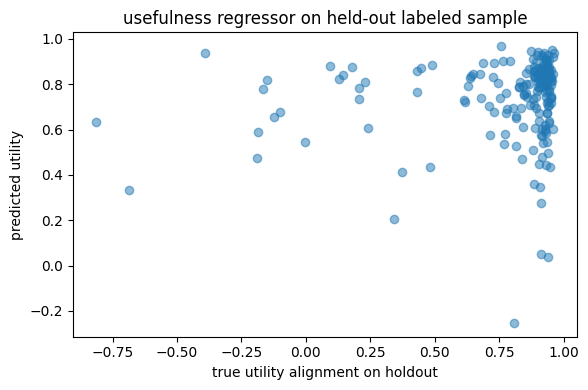

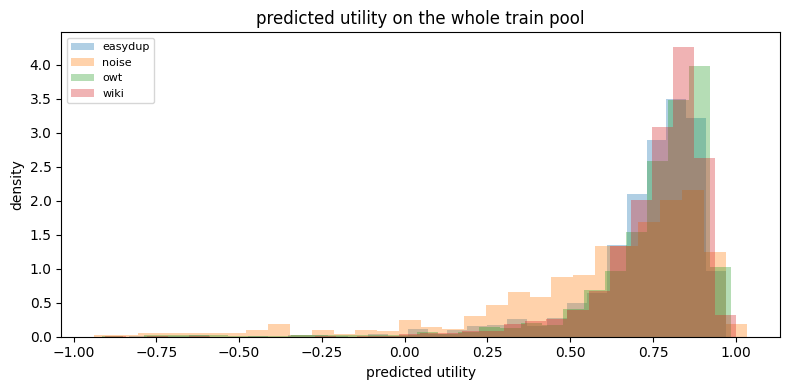

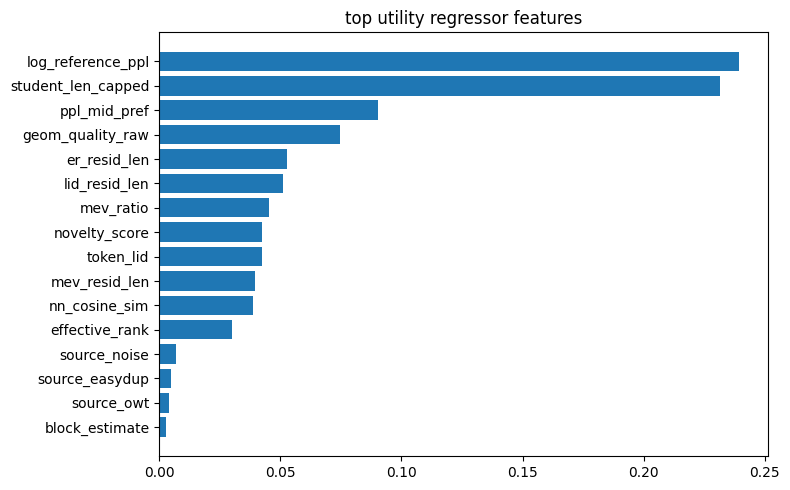

train predicted utility summary


,source,predicted_utility,utility_score,human_prob,verified_score,reference_ppl,effective_rank,token_lid,nn_cosine_sim
0,owt,0.859150,0.552741,1.0,0.260082,54.736408,2.559245,9.887607,0.999309
1,wiki,0.885388,0.515586,1.0,-0.152599,39.989922,3.245735,10.367644,1.000001
2,owt,0.332296,-1.533519,1.0,-0.286113,32.092716,4.553344,9.295602,1.000000
3,owt,0.908329,0.600675,1.0,-0.292616,31.679420,2.547316,11.216345,1.000000
4,owt,0.068434,-2.511151,1.0,-0.241408,34.569386,3.220514,11.648375,1.000000


In [12]:
# ===== 10. usefulness proxy via clean-val gradient alignment =====
utility_cache = BASE_OUT_DIR / "cache" / f"utility_proxy_{UTILITY_FINGERPRINT}.pkl"

def row_group_id(row):
    doc_id = str(row["doc_id"])
    m = re.match(r"^(?:noise|easydup)_from_(.+)_\d+$", doc_id)
    if m:
        return m.group(1)
    return doc_id

def representative_block_from_text(text: str):
    ids = text_ids(text)
    bs = cfg.student_block_size
    if len(ids) < bs + 1:
        return None
    start = max(0, (len(ids) - (bs + 1)) // 2)
    seg = ids[start:start + bs + 1]
    if len(seg) != bs + 1:
        return None
    return np.asarray(seg, dtype=np.int32)

def stratified_sample_indices(df: pd.DataFrame, n: int, seed: int):
    part = df[df["block_estimate"] > 0].copy()
    if len(part) <= n:
        return part.index.tolist()
    counts = part["source"].value_counts()
    alloc = {src: max(1, int(round(n * cnt / len(part)))) for src, cnt in counts.items()}
    while sum(alloc.values()) > n:
        src = max(alloc, key=lambda s: alloc[s])
        if alloc[src] > 1:
            alloc[src] -= 1
    while sum(alloc.values()) < n:
        src = max(counts.index.tolist(), key=lambda s: counts[s] - alloc.get(s, 0))
        alloc[src] = alloc.get(src, 0) + 1

    out = []
    rng = np.random.RandomState(seed)
    for i, (src, grp) in enumerate(part.groupby("source")):
        k = min(len(grp), alloc.get(src, 0))
        if k <= 0:
            continue
        out.extend(grp.sample(n=k, random_state=seed + 101 + i).index.tolist())

    if len(out) < n:
        remain = part.loc[~part.index.isin(out)]
        extra = remain.sample(n=min(n - len(out), len(remain)), random_state=seed + 999).index.tolist()
        out.extend(extra)

    out = out[:n]
    rng.shuffle(out)
    return out

def make_utility_proxy_model():
    cfg_model = GPT2Config(
        vocab_size=student_tokenizer.vocab_size,
        n_positions=cfg.student_block_size,
        n_ctx=cfg.student_block_size,
        n_embd=cfg.utility_proxy_dim,
        n_layer=cfg.utility_proxy_layers,
        n_head=cfg.utility_proxy_heads,
        resid_pdrop=cfg.utility_proxy_dropout,
        embd_pdrop=cfg.utility_proxy_dropout,
        attn_pdrop=cfg.utility_proxy_dropout,
        bos_token_id=student_tokenizer.bos_token_id or student_tokenizer.eos_token_id,
        eos_token_id=student_tokenizer.eos_token_id,
    )
    model = GPT2LMHeadModel(cfg_model)
    return model.to(DEVICE)

def warmup_utility_proxy(model, warmup_blocks_np):
    if cfg.utility_proxy_warmup_steps <= 0 or len(warmup_blocks_np) == 0:
        return {"warmup_steps": 0, "last_loss": None}
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.utility_proxy_lr, weight_decay=0.01)
    gen = torch.Generator(device="cpu")
    gen.manual_seed(cfg.seed + 909)
    last_loss = None
    for step in tqdm(range(cfg.utility_proxy_warmup_steps), desc="utility_proxy_warmup"):
        batch_idx = torch.randint(0, len(warmup_blocks_np), (cfg.utility_proxy_batch_size,), generator=gen)
        batch = torch.tensor(warmup_blocks_np[batch_idx.numpy()], dtype=torch.long, device=DEVICE)
        inputs = batch[:, :-1]
        labels = batch[:, 1:].contiguous()
        out = model(input_ids=inputs, labels=labels)
        loss = out.loss
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        last_loss = float(loss.detach().cpu())
    model.eval()
    return {"warmup_steps": int(cfg.utility_proxy_warmup_steps), "last_loss": float(last_loss)}

def hidden_grad_signatures(model, blocks_np: np.ndarray, batch_size: int):
    sigs = []
    losses = []
    model.eval()
    for start in tqdm(range(0, len(blocks_np), batch_size), desc="utility_signatures"):
        batch_np = blocks_np[start:start + batch_size]
        batch = torch.tensor(batch_np, dtype=torch.long, device=DEVICE)
        inputs = batch[:, :-1]
        labels = batch[:, 1:].contiguous()

        model.zero_grad(set_to_none=True)
        tr = model.transformer(input_ids=inputs)
        hidden = tr.last_hidden_state
        hidden.retain_grad()
        logits = model.lm_head(hidden)

        tok_losses = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
            reduction="none",
        ).reshape(inputs.size(0), -1)
        per_ex = tok_losses.mean(dim=1)
        loss = per_ex.sum()
        loss.backward()

        grad_hidden = hidden.grad.detach().mean(dim=1).cpu().numpy().astype(np.float32)
        sigs.append(grad_hidden)
        losses.extend(per_ex.detach().cpu().numpy().astype(float).tolist())

        model.zero_grad(set_to_none=True)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    sigs = np.concatenate(sigs, axis=0)
    losses = np.asarray(losses, dtype=np.float64)
    return sigs, losses

def l2_normalize_rows(X: np.ndarray):
    X = np.asarray(X, dtype=np.float32)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.clip(norms, 1e-8, None)

def spearman_np(a, b):
    ra = pd.Series(np.asarray(a)).rank(method="average").values
    rb = pd.Series(np.asarray(b)).rank(method="average").values
    if np.std(ra) < 1e-12 or np.std(rb) < 1e-12:
        return 0.0
    return float(np.corrcoef(ra, rb)[0, 1])

def make_utility_feature_frame(df: pd.DataFrame) -> pd.DataFrame:
    X = pd.DataFrame({
        "effective_rank": df["effective_rank"].astype(float).values,
        "token_lid": df["token_lid"].astype(float).values,
        "mev_ratio": df["mev_ratio"].astype(float).values,
        "er_resid_len": df["er_resid_len"].astype(float).values,
        "lid_resid_len": df["lid_resid_len"].astype(float).values,
        "mev_resid_len": df["mev_resid_len"].astype(float).values,
        "geom_quality_raw": df["geom_quality_raw"].astype(float).values,
        "log_reference_ppl": np.log(np.clip(df["reference_ppl"].astype(float).values, 1e-6, None)),
        "ppl_mid_pref": df["ppl_mid_pref"].astype(float).values,
        "novelty_score": df["novelty_score"].astype(float).values,
        "nn_cosine_sim": df["nn_cosine_sim"].astype(float).values,
        "teacher_len": df["teacher_len"].astype(float).values,
        "student_len_capped": df["student_len_capped"].astype(float).values,
        "block_estimate": df["block_estimate"].astype(float).values,
    })
    src_dum = pd.get_dummies(df["source"], prefix="source")
    X = pd.concat([X.reset_index(drop=True), src_dum.reset_index(drop=True)], axis=1)
    return X

if utility_cache.exists() and not cfg.force_rebuild_utility:
    utility_art = load_pickle(utility_cache)
    utility_label_df = utility_art["utility_label_df"]
    utility_summary = utility_art["utility_summary"]
    utility_feature_cols = utility_art["utility_feature_cols"]
    utility_reg = utility_art["utility_reg"]
else:
    warmup_df = train_pool[train_pool["block_estimate"] > 0].sample(
        n=min(cfg.utility_proxy_warmup_examples, int((train_pool["block_estimate"] > 0).sum())),
        random_state=cfg.seed + 555
    ).copy()
    warmup_blocks = build_blocks_from_texts(warmup_df["text"].tolist(), "utility_proxy_warmup_texts")

    utility_proxy = make_utility_proxy_model()
    warmup_report = warmup_utility_proxy(utility_proxy, warmup_blocks)

    anchor_blocks = clean_val_blocks[: min(len(clean_val_blocks), cfg.utility_anchor_blocks)]
    anchor_sig, anchor_losses = hidden_grad_signatures(
        utility_proxy,
        anchor_blocks,
        batch_size=cfg.utility_proxy_batch_size,
    )
    anchor_sig = l2_normalize_rows(anchor_sig)
    anchor_vec = anchor_sig.mean(axis=0, keepdims=True)
    anchor_vec = l2_normalize_rows(anchor_vec)[0]

    sampled_idx = stratified_sample_indices(train_pool, cfg.utility_label_sample_n, cfg.seed + 707)
    utility_label_df = train_pool.loc[sampled_idx].copy().reset_index(drop=True)
    utility_blocks = []
    keep_rows = []
    for i, row in utility_label_df.iterrows():
        block = representative_block_from_text(row["text"])
        if block is None:
            continue
        utility_blocks.append(block)
        keep_rows.append(i)
    utility_label_df = utility_label_df.iloc[keep_rows].copy().reset_index(drop=True)
    utility_blocks = np.stack(utility_blocks)

    utility_sig, utility_losses = hidden_grad_signatures(
        utility_proxy,
        utility_blocks,
        batch_size=cfg.utility_proxy_batch_size,
    )
    utility_sig = l2_normalize_rows(utility_sig)
    utility_alignment = (utility_sig @ anchor_vec).astype(np.float32)

    utility_label_df["utility_alignment_true"] = utility_alignment
    utility_label_df["utility_proxy_loss"] = utility_losses
    utility_label_df["utility_group_id"] = utility_label_df.apply(row_group_id, axis=1)

    groups = pd.Series(utility_label_df["utility_group_id"].drop_duplicates()).sample(
        frac=1.0, random_state=cfg.seed
    ).tolist()
    cut = max(1, int(len(groups) * (1.0 - cfg.utility_holdout_frac)))
    train_groups = set(groups[:cut])
    test_groups = set(groups[cut:])
    utility_label_df["utility_split"] = np.where(
        utility_label_df["utility_group_id"].isin(train_groups),
        "train",
        "test",
    )

    X_all = make_utility_feature_frame(utility_label_df)
    utility_feature_cols = X_all.columns.tolist()
    X_tr = X_all[utility_label_df["utility_split"] == "train"]
    y_tr = utility_label_df.loc[utility_label_df["utility_split"] == "train", "utility_alignment_true"].values.astype(float)
    X_te = X_all[utility_label_df["utility_split"] == "test"]
    y_te = utility_label_df.loc[utility_label_df["utility_split"] == "test", "utility_alignment_true"].values.astype(float)

    utility_reg = GradientBoostingRegressor(
        random_state=cfg.seed,
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
    )
    utility_reg.fit(X_tr, y_tr)

    utility_label_df["predicted_utility_local"] = utility_reg.predict(X_all)
    pred_te = utility_label_df.loc[utility_label_df["utility_split"] == "test", "predicted_utility_local"].values.astype(float)

    k = max(1, int(len(y_te) * cfg.utility_topk_eval_frac))
    top_idx = np.argsort(-pred_te)[:k]
    top_mean_true = float(np.mean(y_te[top_idx]))
    rand_means = []
    rng = np.random.RandomState(cfg.seed + 808)
    for _ in range(128):
        ridx = rng.choice(len(y_te), size=k, replace=False)
        rand_means.append(float(np.mean(y_te[ridx])))
    rand_means = np.asarray(rand_means, dtype=np.float64)
    top_vs_random_zgap = float((top_mean_true - rand_means.mean()) / max(rand_means.std(ddof=1), 1e-8))

    utility_summary = {
        "n_labeled_examples": int(len(utility_label_df)),
        "n_train_labels": int((utility_label_df["utility_split"] == "train").sum()),
        "n_test_labels": int((utility_label_df["utility_split"] == "test").sum()),
        "anchor_blocks": int(len(anchor_blocks)),
        "anchor_loss_mean": float(np.mean(anchor_losses)),
        "warmup_report": warmup_report,
        "holdout_spearman": float(spearman_np(y_te, pred_te)),
        "holdout_rmse": float(math.sqrt(mean_squared_error(y_te, pred_te))),
        "holdout_topk_true_alignment_mean": top_mean_true,
        "holdout_random_true_alignment_mean": float(rand_means.mean()),
        "holdout_topk_vs_random_zgap": top_vs_random_zgap,
        "source_alignment_means": utility_label_df.groupby("source")["utility_alignment_true"].mean().to_dict(),
    }

    save_pickle(
        {
            "utility_label_df": utility_label_df,
            "utility_summary": utility_summary,
            "utility_feature_cols": utility_feature_cols,
            "utility_reg": utility_reg,
        },
        utility_cache,
    )

print(json.dumps(utility_summary, indent=2))
save_json(utility_summary, BASE_OUT_DIR / "utility_proxy_summary.json")

full_X = make_utility_feature_frame(train_pool)
missing_cols = [c for c in utility_feature_cols if c not in full_X.columns]
for c in missing_cols:
    full_X[c] = 0.0
full_X = full_X[utility_feature_cols]
train_pool["predicted_utility"] = utility_reg.predict(full_X)
train_pool["utility_score"] = (
    (1.0 - cfg.utility_blend_novelty) * zscore(train_pool["predicted_utility"].values) +
    cfg.utility_blend_novelty * zscore(train_pool["novelty_score"].values)
)

utility_label_df.to_csv(BASE_OUT_DIR / "utility_label_df.csv", index=False)

plt.figure(figsize=(6, 4))
te = utility_label_df[utility_label_df["utility_split"] == "test"].copy()
plt.scatter(te["utility_alignment_true"], te["predicted_utility_local"], alpha=0.5)
plt.xlabel("true utility alignment on holdout")
plt.ylabel("predicted utility")
plt.title("usefulness regressor on held-out labeled sample")
plt.tight_layout()
plt.savefig(BASE_OUT_DIR / "plots" / "utility_holdout_scatter.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
for src, grp in train_pool.groupby("source"):
    plt.hist(grp["predicted_utility"], bins=30, alpha=0.35, label=src, density=True)
plt.xlabel("predicted utility")
plt.ylabel("density")
plt.title("predicted utility on the whole train pool")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(BASE_OUT_DIR / "plots" / "predicted_utility_train_hist.png", dpi=150)
plt.show()

if hasattr(utility_reg, "feature_importances_"):
    feat_imp = pd.DataFrame({
        "feature": utility_feature_cols,
        "importance": utility_reg.feature_importances_,
    }).sort_values("importance", ascending=False).head(16)
    feat_imp.to_csv(BASE_OUT_DIR / "utility_feature_importance_top.csv", index=False)
    plt.figure(figsize=(8, 5))
    plt.barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1])
    plt.title("top utility regressor features")
    plt.tight_layout()
    plt.savefig(BASE_OUT_DIR / "plots" / "utility_feature_importance_top.png", dpi=150)
    plt.show()

print("train predicted utility summary")
display(train_pool[[
    "source", "predicted_utility", "utility_score", "human_prob", "verified_score",
    "reference_ppl", "effective_rank", "token_lid", "nn_cosine_sim"
]].head())


In [13]:

# ===== 11. selections by realized train-block budget =====
sel_cache = BASE_OUT_DIR / "cache" / f"selections_{SEL_FINGERPRINT}.pkl"

def block_budget_from_fraction(df, frac):
    return int(np.floor(df["block_estimate"].sum() * frac))

def fill_order_to_budget(order_df, budget_blocks):
    order_df = order_df[order_df["block_estimate"] > 0].copy()
    selected = []
    selected_set = set()
    total = 0

    for _, row in order_df.iterrows():
        rid = int(row["row_id"])
        cost = int(row["block_estimate"])
        if rid in selected_set:
            continue
        if total + cost <= budget_blocks:
            selected.append(rid)
            selected_set.add(rid)
            total += cost

    if total >= budget_blocks:
        return selected

    candidates = order_df[~order_df["row_id"].isin(selected_set)].copy()
    if len(candidates) == 0:
        return selected

    reach = candidates[candidates["block_estimate"] + total >= budget_blocks].copy()
    if len(reach) > 0:
        reach["overshoot"] = reach["block_estimate"] + total - budget_blocks
        reach = reach.sort_values(["overshoot", "block_estimate"], ascending=[True, True], kind="mergesort")
        rid = int(reach.iloc[0]["row_id"])
        selected.append(rid)
        return selected

    candidates = candidates.sort_values(["block_estimate"], ascending=[False], kind="mergesort")
    rid = int(candidates.iloc[0]["row_id"])
    selected.append(rid)
    return selected

def selection_random(df, frac, seed):
    budget = block_budget_from_fraction(df, frac)
    part = df[df["block_estimate"] > 0].sample(frac=1.0, random_state=seed)
    return fill_order_to_budget(part, budget)

def selection_perplexity_mid(df, frac, seed):
    budget = block_budget_from_fraction(df, frac)
    part = df[df["block_estimate"] > 0].sample(frac=1.0, random_state=seed)
    part = part.sort_values(["ppl_mid_pref", "block_estimate"], ascending=[False, True], kind="mergesort")
    return fill_order_to_budget(part, budget)

def build_source_balanced_order(df, frac, seed, score_col, prefilter_mul, synthetic_cap_share, human_prob_floor=None):
    part = df[df["block_estimate"] > 0].copy()
    if len(part) == 0:
        return part

    if (human_prob_floor is not None) and ("human_prob" in part.columns):
        part = part[(part["human_prob"] >= human_prob_floor) | (~part["source"].isin(["noise", "easydup"]))]

    budget = block_budget_from_fraction(part, frac)
    target_blocks = max(1, budget)
    mean_cost = max(1.0, float(part["block_estimate"].mean()))
    target_items = int(np.ceil(target_blocks / mean_cost))
    pre_k = min(len(part), max(target_items + 48, int(target_items * prefilter_mul)))

    part = part.sample(frac=1.0, random_state=seed).sort_values(
        [score_col, "novelty_score", "block_estimate"],
        ascending=[False, False, True],
        kind="mergesort",
    ).head(pre_k).copy()
    if len(part) == 0:
        return part

    clean_mass = train_pool[train_pool["source"].isin(["wiki", "owt"])].groupby("source")["block_estimate"].sum()
    total_clean = clean_mass.sum()
    base_weights = {
        "wiki": float(clean_mass.get("wiki", 0.0) / max(total_clean, 1)),
        "owt": float(clean_mass.get("owt", 0.0) / max(total_clean, 1)),
    }
    syn_cap = synthetic_cap_share
    clean_scale = 1.0 - syn_cap
    weight_map = {
        "wiki": clean_scale * base_weights["wiki"],
        "owt": clean_scale * base_weights["owt"],
        "easydup": syn_cap * 0.75,
        "noise": syn_cap * 0.25,
    }

    present_sources = [s for s in ["wiki", "owt", "easydup", "noise"] if (part["source"] == s).any()]
    total_w = sum(weight_map[s] for s in present_sources)
    weight_map = {s: weight_map[s] / total_w for s in present_sources}

    lists = {}
    for s in present_sources:
        sub = part[part["source"] == s].copy()
        cluster_block_mass = sub.groupby("cluster_id")["block_estimate"].sum().sort_index()
        cluster_ids = [int(c) for c in cluster_block_mass.index.tolist()]
        cluster_w = np.sqrt(cluster_block_mass.values.astype(np.float64))
        cluster_w = cluster_w / cluster_w.sum()

        by_cluster = {}
        for c in cluster_ids:
            ss = sub[sub["cluster_id"] == c].sample(frac=1.0, random_state=seed + int(c))
            ss = ss.sort_values(
                [score_col, "novelty_score", "block_estimate"],
                ascending=[False, False, True],
                kind="mergesort",
            )
            by_cluster[c] = ss.to_dict("records")

        curs = {c: 0 for c in cluster_ids}
        taken = {c: 0 for c in cluster_ids}
        total_taken = 0
        out_rows = []
        while True:
            active = [c for c in cluster_ids if curs[c] < len(by_cluster[c])]
            if not active:
                break
            best_c = None
            best_score = None
            denom = max(1, total_taken)
            for c, w in zip(cluster_ids, cluster_w):
                if c not in active:
                    continue
                expected = w * denom
                deficit = expected - taken[c]
                score = (deficit, w, -c)
                if best_score is None or score > best_score:
                    best_score = score
                    best_c = c
            out_rows.append(by_cluster[best_c][curs[best_c]])
            curs[best_c] += 1
            taken[best_c] += 1
            total_taken += 1
        lists[s] = out_rows

    curs_s = {s: 0 for s in present_sources}
    taken_s = {s: 0 for s in present_sources}
    total_taken_s = 0
    order_rows = []

    while True:
        active_s = [s for s in present_sources if curs_s[s] < len(lists[s])]
        if not active_s:
            break
        best_s = None
        best_score = None
        denom = max(1, total_taken_s)
        for s in active_s:
            expected = weight_map[s] * denom
            deficit = expected - taken_s[s]
            score = (deficit, weight_map[s], s)
            if best_score is None or score > best_score:
                best_score = score
                best_s = s
        order_rows.append(lists[best_s][curs_s[best_s]])
        curs_s[best_s] += 1
        taken_s[best_s] += 1
        total_taken_s += 1

    return pd.DataFrame(order_rows)

def selection_verified_source_cluster(df, frac, seed):
    budget = block_budget_from_fraction(df, frac)
    part = build_source_balanced_order(
        df,
        frac=frac,
        seed=seed,
        score_col="verified_score",
        prefilter_mul=cfg.verified_prefilter_mul,
        synthetic_cap_share=cfg.synthetic_cap_share,
        human_prob_floor=cfg.verified_min_human_prob,
    )
    return fill_order_to_budget(part, budget)

def selection_utility_source_cluster(df, frac, seed):
    budget = block_budget_from_fraction(df, frac)
    part = build_source_balanced_order(
        df,
        frac=frac,
        seed=seed,
        score_col="utility_score",
        prefilter_mul=cfg.utility_prefilter_mul,
        synthetic_cap_share=cfg.utility_synthetic_cap_share,
        human_prob_floor=None,
    )
    return fill_order_to_budget(part, budget)

def selection_mmr(df, frac, seed, score_col, prefilter_mul, human_prob_floor=None, mmr_lambda=0.76):
    budget = block_budget_from_fraction(df, frac)
    part = df[df["block_estimate"] > 0].copy()
    if len(part) == 0:
        return []

    if (human_prob_floor is not None) and ("human_prob" in part.columns):
        part = part[(part["human_prob"] >= human_prob_floor) | (~part["source"].isin(["noise", "easydup"]))]

    target_blocks = max(1, budget)
    mean_cost = max(1.0, float(part["block_estimate"].mean()))
    target_items = int(np.ceil(target_blocks / mean_cost))
    pre_k = min(len(part), max(target_items + 48, int(target_items * prefilter_mul)))

    part = part.sample(frac=1.0, random_state=seed).sort_values(
        [score_col, "block_estimate"],
        ascending=[False, True],
        kind="mergesort",
    ).head(pre_k).reset_index(drop=True)
    if len(part) == 0:
        return []

    embs = np.stack(part["teacher_emb"].values).astype(np.float32)
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    embs = embs / np.clip(norms, 1e-8, None)
    q = zscore(part[score_col].values.astype(np.float64))

    selected = []
    selected_mask = np.zeros(len(part), dtype=bool)
    max_sim = np.zeros(len(part), dtype=np.float32)
    total_blocks = 0

    source_bonus = np.where(part["source"].isin(["wiki", "owt"]).values, 0.05, 0.0)
    first = int(np.argmax(q + source_bonus))
    selected.append(first)
    selected_mask[first] = True
    total_blocks += int(part.iloc[first]["block_estimate"])
    max_sim = np.maximum(max_sim, embs @ embs[first])

    while total_blocks < budget and (~selected_mask).any():
        score = mmr_lambda * (q + source_bonus) - (1.0 - mmr_lambda) * max_sim
        score[selected_mask] = -1e9
        cand = int(np.argmax(score))
        selected.append(cand)
        selected_mask[cand] = True
        total_blocks += int(part.iloc[cand]["block_estimate"])
        max_sim = np.maximum(max_sim, embs @ embs[cand])

    order = part.iloc[selected][["row_id", "block_estimate", score_col]].copy()
    return fill_order_to_budget(order, budget)

def selection_utility_mmr(df, frac, seed, mmr_lambda=0.76):
    return selection_mmr(
        df,
        frac=frac,
        seed=seed,
        score_col="utility_score",
        prefilter_mul=cfg.utility_prefilter_mul,
        human_prob_floor=None,
        mmr_lambda=mmr_lambda,
    )

def build_curriculum_from_selector(df, selector_name, seed):
    fracs = list(cfg.curriculum_fractions)
    schedule = {}
    for frac in fracs:
        schedule[float(frac)] = get_selection(selector_name, float(frac), seed)
    accum = []
    accum_set = set()
    nested_schedule = {}
    for frac in sorted(schedule.keys()):
        for rid in schedule[frac]:
            if rid not in accum_set:
                accum.append(rid)
                accum_set.add(rid)
        nested_schedule[frac] = list(accum)
    return nested_schedule

SUBSET_METHODS = ["random", "perplexity_mid", "utility_source_cluster"]
if cfg.run_utility_mmr:
    SUBSET_METHODS.append("utility_mmr")
if cfg.run_verified_baseline:
    SUBSET_METHODS.append("verified_source_cluster")

CURRICULUM_METHODS = ["random", "utility_source_cluster"]

if sel_cache.exists() and not cfg.force_rebuild_selections:
    selections = load_pickle(sel_cache)
else:
    selections = {}

def get_selection(method, frac, seed):
    frac = float(frac)
    key = f"{method}|{frac:.3f}|{seed}"
    if key in selections and not cfg.force_rebuild_selections:
        return selections[key]
    if method == "random":
        idx = selection_random(train_pool, frac, seed)
    elif method == "perplexity_mid":
        idx = selection_perplexity_mid(train_pool, frac, seed)
    elif method == "utility_source_cluster":
        idx = selection_utility_source_cluster(train_pool, frac, seed)
    elif method == "utility_mmr":
        idx = selection_utility_mmr(train_pool, frac, seed)
    elif method == "verified_source_cluster":
        idx = selection_verified_source_cluster(train_pool, frac, seed)
    else:
        raise ValueError(method)
    selections[key] = idx
    save_pickle(selections, sel_cache)
    return idx

selection_diag_rows = []
for frac in list(SUBSET_FRACTIONS) + [FULL_FRACTION]:
    for meth in SUBSET_METHODS:
        idx = get_selection(meth, min(float(frac), 1.0), DIAGNOSTIC_SEED)
        blocks = int(train_pool.set_index("row_id").loc[idx]["block_estimate"].sum())
        selection_diag_rows.append({
            "method": meth,
            "fraction": float(frac),
            "seed": int(DIAGNOSTIC_SEED),
            "selected_examples": int(len(idx)),
            "realized_blocks": blocks,
        })
selection_diag_df = pd.DataFrame(selection_diag_rows)
display(selection_diag_df.sort_values(["fraction", "method"]))


,method,fraction,seed,selected_examples,realized_blocks
1,perplexity_mid,0.1,11,416,445
0,random,0.1,11,413,445
3,utility_mmr,0.1,11,410,445
2,utility_source_cluster,0.1,11,428,445
5,perplexity_mid,0.3,11,1236,1335
4,random,0.3,11,1216,1335
7,utility_mmr,0.3,11,1278,1335
6,utility_source_cluster,0.3,11,1296,1335
9,perplexity_mid,0.7,11,2891,3115
8,random,0.7,11,2828,3115


,metric,mean,std,q10,q25,q50,q75,q90,q95,share_ge_0_5,share_ge_0_7,share_ge_0_8,share_ge_0_9
0,effective_rank,4.255147e+00,1.203497,2.820534,3.382277,4.117189,4.949389,5.876905,6.523608,1.000000,1.000000,1.000000,1.000000
1,token_lid,1.042449e+01,1.194304,8.960743,9.665109,10.437951,11.200118,11.945015,12.360846,1.000000,1.000000,1.000000,1.000000
2,human_prob,9.995247e-01,0.019847,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.999444,0.999444,0.999444,0.999444
3,verified_score,-4.123122e-15,0.652881,-0.275016,-0.117714,0.044542,0.198862,0.310250,0.383043,0.015370,0.004444,0.003333,0.002407
4,predicted_utility,7.237400e-01,0.229417,0.487631,0.673322,0.786135,0.859372,0.903523,0.921750,0.894259,0.705556,0.459074,0.112593
5,utility_score,1.197396e-16,0.838583,-0.873499,-0.189210,0.226136,0.497698,0.661886,0.742305,0.247037,0.074074,0.026667,0.009815
6,reference_ppl,7.545063e+01,55.889287,27.350887,39.423725,60.903526,93.543985,136.995102,177.179709,1.000000,1.000000,1.000000,1.000000


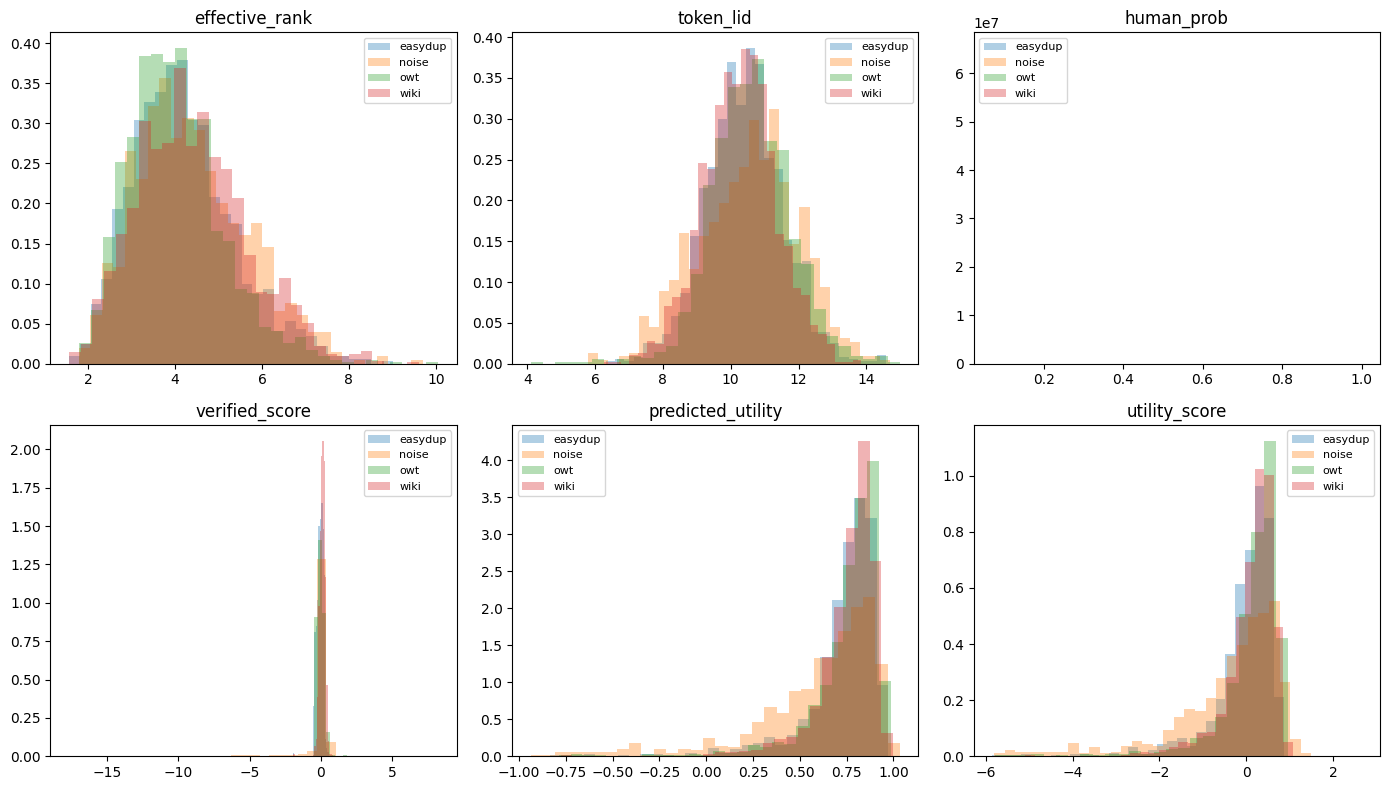

,metric,budget_blocks,topk_metric_mean,random_metric_mean_mean,random_metric_mean_std,topk_vs_random_zgap,random_prob_topk_better_or_equal,topk_bad_mass,random_mean_bad_mass,topk_mean_utility_score,random_mean_utility_score
0,human_prob,1335,1.000000,1.000000,5.910982e-17,0.000000,0.929688,0.356554,0.369748,0.119824,0.002756
1,verified_score,1335,0.311090,0.031252,6.938670e-03,40.330100,0.000000,0.286318,0.369748,-0.013395,0.002756
2,predicted_utility,1335,0.890142,0.723747,5.705260e-03,29.165193,0.000000,0.309707,0.369748,0.603109,0.002756
3,utility_score,1335,0.623420,0.002756,2.074509e-02,29.918564,0.000000,0.285043,0.369748,0.623420,0.002756


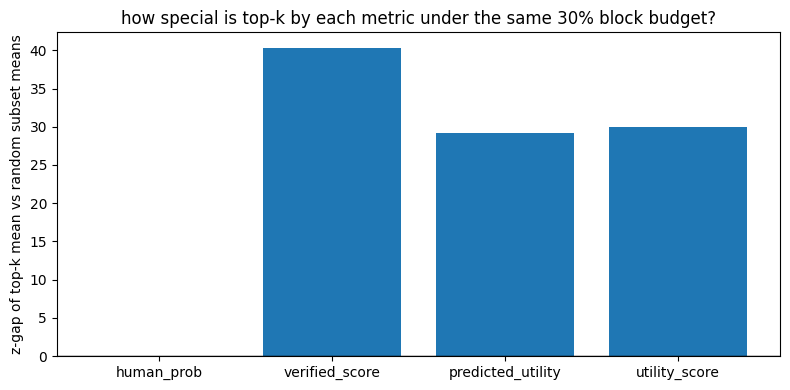

heuristic reading:
- human_prob: metric looks saturated / weak for direct top-k
- verified_score: metric is far from saturated; direct ranking changes the subset a lot
- predicted_utility: metric is far from saturated; direct ranking changes the subset a lot
- utility_score: metric is far from saturated; direct ranking changes the subset a lot
utility holdout top-k true alignment = 0.800578773021698
utility holdout random true alignment mean = 0.7674823962152004
utility holdout top-k vs random z-gap = 0.9347421645977748


In [14]:
# ===== 12. metric saturation diagnostics on the whole train pool =====
def summarize_metric_distribution(df: pd.DataFrame, metric: str, thresholds=(0.5, 0.7, 0.8, 0.9)):
    vals = df[metric].values.astype(float)
    out = {
        "metric": metric,
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "q10": float(np.quantile(vals, 0.10)),
        "q25": float(np.quantile(vals, 0.25)),
        "q50": float(np.quantile(vals, 0.50)),
        "q75": float(np.quantile(vals, 0.75)),
        "q90": float(np.quantile(vals, 0.90)),
        "q95": float(np.quantile(vals, 0.95)),
    }
    for t in thresholds:
        out[f"share_ge_{str(t).replace('.', '_')}"] = float((vals >= t).mean())
    return out

metrics_to_check = ["effective_rank", "token_lid", "human_prob", "verified_score", "predicted_utility", "utility_score", "reference_ppl"]
dist_rows = [summarize_metric_distribution(train_pool, m) for m in metrics_to_check]
dist_df = pd.DataFrame(dist_rows)
dist_df.to_csv(BASE_OUT_DIR / "metric_distribution_summary.csv", index=False)
display(dist_df)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
plot_metrics = ["effective_rank", "token_lid", "human_prob", "verified_score", "predicted_utility", "utility_score"]
for ax, metric in zip(axes.ravel(), plot_metrics):
    for src, grp in train_pool.groupby("source"):
        ax.hist(grp[metric], bins=30, alpha=0.35, label=src, density=True)
    ax.set_title(metric)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(BASE_OUT_DIR / "plots" / "metric_distributions_by_source.png", dpi=150)
plt.show()

budget_blocks = block_budget_from_fraction(train_pool, cfg.subset_fraction)

def topk_mean_by_metric(df: pd.DataFrame, metric: str, ascending: bool = False):
    part = df[df["block_estimate"] > 0].sample(frac=1.0, random_state=cfg.seed).copy()
    part = part.sort_values([metric, "block_estimate"], ascending=[ascending, True], kind="mergesort")
    idx = fill_order_to_budget(part, budget_blocks)
    sub = df.set_index("row_id").loc[idx].reset_index()
    return idx, sub

sat_rows = []
for metric in ["human_prob", "verified_score", "predicted_utility", "utility_score"]:
    idx_top, top_sub = topk_mean_by_metric(train_pool, metric, ascending=False)
    rand_means = []
    rand_bad = []
    rand_util = []
    for j in range(cfg.saturation_random_trials):
        idx_r = selection_random(train_pool, cfg.subset_fraction, cfg.seed + 10_000 + j)
        sub_r = train_pool.set_index("row_id").loc[idx_r].reset_index()
        rand_means.append(float(sub_r[metric].mean()))
        rand_bad.append(float(((sub_r["source"] == "noise") | (sub_r["source"] == "easydup")).mean()))
        rand_util.append(float(sub_r["utility_score"].mean()))
    rand_means = np.asarray(rand_means, dtype=float)
    gap_std = float((top_sub[metric].mean() - rand_means.mean()) / max(rand_means.std(ddof=1), 1e-8))
    sat_rows.append({
        "metric": metric,
        "budget_blocks": int(budget_blocks),
        "topk_metric_mean": float(top_sub[metric].mean()),
        "random_metric_mean_mean": float(rand_means.mean()),
        "random_metric_mean_std": float(rand_means.std(ddof=1)),
        "topk_vs_random_zgap": gap_std,
        "random_prob_topk_better_or_equal": float((rand_means >= float(top_sub[metric].mean())).mean()),
        "topk_bad_mass": float(((top_sub["source"] == "noise") | (top_sub["source"] == "easydup")).mean()),
        "random_mean_bad_mass": float(np.mean(rand_bad)),
        "topk_mean_utility_score": float(top_sub["utility_score"].mean()),
        "random_mean_utility_score": float(np.mean(rand_util)),
    })

sat_df = pd.DataFrame(sat_rows)
sat_df.to_csv(BASE_OUT_DIR / "metric_saturation_checks.csv", index=False)
display(sat_df)

plt.figure(figsize=(8, 4))
plt.bar(sat_df["metric"], sat_df["topk_vs_random_zgap"])
plt.axhline(0.0, color="black", linewidth=1)
plt.ylabel("z-gap of top-k mean vs random subset means")
plt.title("how special is top-k by each metric under the same 30% block budget?")
plt.tight_layout()
plt.savefig(BASE_OUT_DIR / "plots" / "metric_saturation_zgap.png", dpi=150)
plt.show()

print("heuristic reading:")
for _, row in sat_df.iterrows():
    if row["topk_vs_random_zgap"] < 1.0:
        msg = "metric looks saturated / weak for direct top-k"
    elif row["topk_vs_random_zgap"] < 2.0:
        msg = "metric has some headroom but random is still competitive"
    else:
        msg = "metric is far from saturated; direct ranking changes the subset a lot"
    print(f"- {row['metric']}: {msg}")

if "utility_split" in utility_label_df.columns:
    te = utility_label_df[utility_label_df["utility_split"] == "test"].copy()
    k = max(1, int(len(te) * cfg.utility_topk_eval_frac))
    top_true = te.sort_values("predicted_utility_local", ascending=False).head(k)["utility_alignment_true"].mean()
    rand_means = []
    for j in range(128):
        rand_means.append(float(te.sample(n=k, random_state=cfg.seed + 20_000 + j)["utility_alignment_true"].mean()))
    rand_means = np.asarray(rand_means)
    print("utility holdout top-k true alignment =", float(top_true))
    print("utility holdout random true alignment mean =", float(rand_means.mean()))
    print("utility holdout top-k vs random z-gap =", float((top_true - rand_means.mean()) / max(rand_means.std(ddof=1), 1e-8)))


,method,fraction,seed,n_examples,n_unique_docs,realized_blocks,mean_teacher_len,mean_student_len_capped,mean_reference_ppl,mean_effective_rank,...,mean_predicted_utility,mean_utility_score,mean_novelty_score,wiki_share,owt_share,noise_share,easydup_share,bad_mass,probe_auc,utility_holdout_spearman
1,perplexity_mid,0.1,11,416,389,445,128.000000,155.000000,69.905559,4.271383,...,0.712339,-5.844699e-02,-1.080362e-01,0.415865,0.225962,0.088942,0.269231,0.358173,0.979219,0.12608
0,random,0.1,11,413,397,445,128.000000,156.629540,72.637942,4.229376,...,0.709311,-5.191462e-02,1.029156e-02,0.278450,0.363196,0.128329,0.230024,0.358354,0.979219,0.12608
3,utility_mmr,0.1,11,410,367,445,128.000000,152.431707,43.458205,3.558027,...,0.911533,7.775502e-01,5.451180e-01,0.241463,0.492683,0.173171,0.092683,0.265854,0.979219,0.12608
2,utility_source_cluster,0.1,11,428,375,445,128.000000,147.408879,43.610556,3.701573,...,0.902856,7.211215e-01,3.832549e-01,0.383178,0.535047,0.021028,0.060748,0.081776,0.979219,0.12608
5,perplexity_mid,0.3,11,1236,1050,1335,128.000000,155.790453,70.138615,4.321932,...,0.705936,-8.116138e-02,-1.013146e-01,0.418285,0.235437,0.086570,0.259709,0.346278,0.979219,0.12608
4,random,0.3,11,1216,1062,1335,128.000000,158.176809,68.651717,4.175052,...,0.720683,-1.068330e-02,4.285992e-03,0.266447,0.369243,0.111020,0.253289,0.364309,0.979219,0.12608
7,utility_mmr,0.3,11,1278,1027,1335,128.000000,150.692488,49.839985,3.885033,...,0.885146,6.231986e-01,1.678861e-01,0.274648,0.449922,0.109546,0.165884,0.275430,0.979219,0.12608
6,utility_source_cluster,0.3,11,1296,937,1335,128.000000,149.823302,52.778138,4.020621,...,0.856249,5.159060e-01,1.663479e-01,0.382716,0.537037,0.020062,0.060185,0.080247,0.979219,0.12608
9,perplexity_mid,0.7,11,2891,2161,3115,128.000000,156.227949,74.749793,4.307981,...,0.721730,-1.840525e-02,-7.305816e-02,0.359391,0.281909,0.109997,0.248703,0.358699,0.979219,0.12608
8,random,0.7,11,2828,2145,3115,128.000000,158.856436,68.049199,4.215674,...,0.717868,-2.161043e-02,9.727597e-04,0.269095,0.355021,0.119873,0.256011,0.375884,0.979219,0.12608


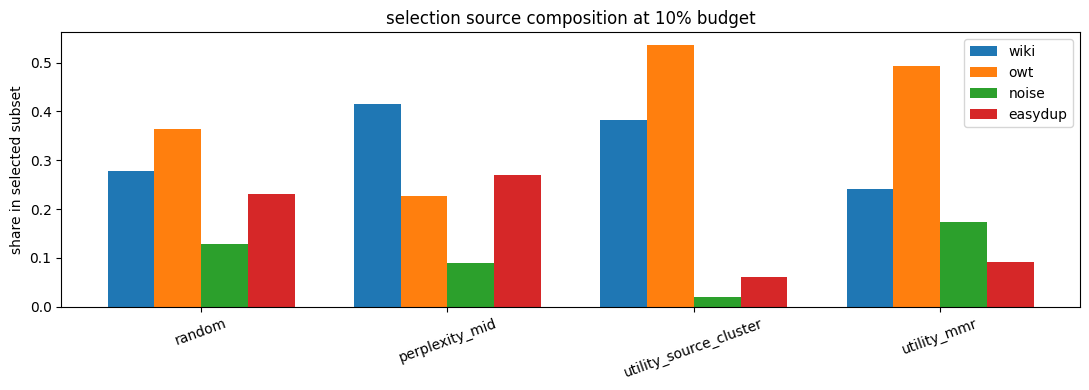

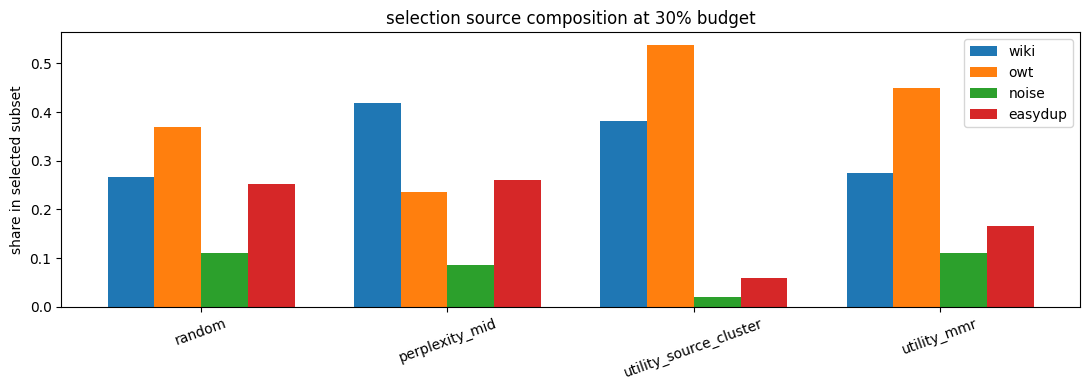

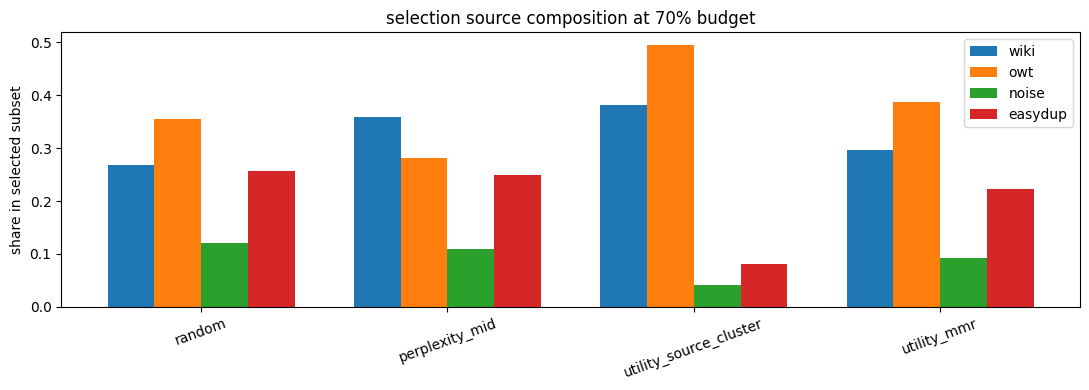

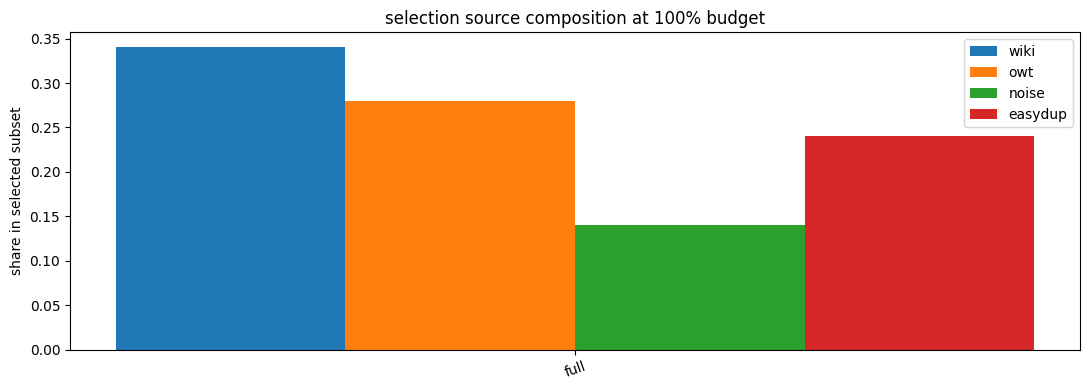

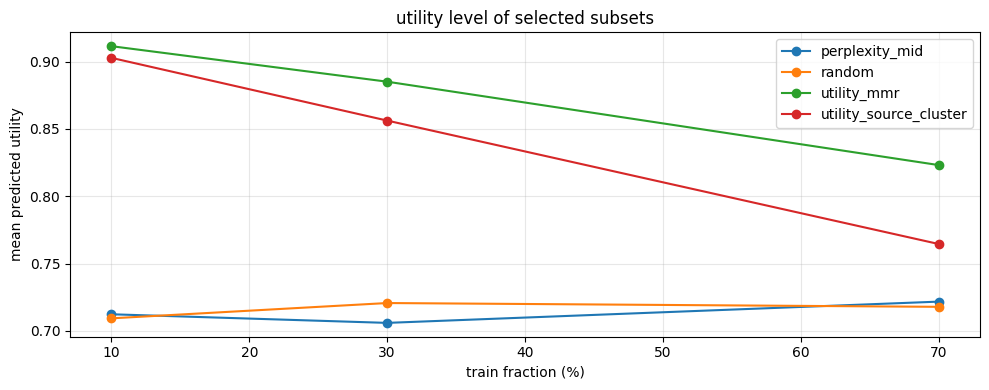

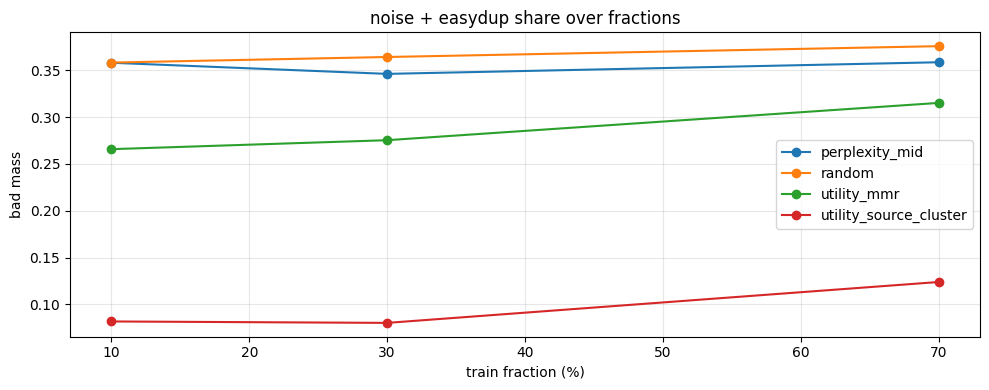

,method,fraction,realized_blocks,bad_mass,mean_human_prob,mean_predicted_utility,mean_utility_score,mean_reference_ppl,mean_novelty_score
3,utility_mmr,0.1,445,0.265854,1.000000,0.911533,7.775502e-01,43.458205,5.451180e-01
2,utility_source_cluster,0.1,445,0.081776,1.000000,0.902856,7.211215e-01,43.610556,3.832549e-01
1,perplexity_mid,0.1,445,0.358173,1.000000,0.712339,-5.844699e-02,69.905559,-1.080362e-01
0,random,0.1,445,0.358354,1.000000,0.709311,-5.191462e-02,72.637942,1.029156e-02
7,utility_mmr,0.3,1335,0.275430,1.000000,0.885146,6.231986e-01,49.839985,1.678861e-01
6,utility_source_cluster,0.3,1335,0.080247,1.000000,0.856249,5.159060e-01,52.778138,1.663479e-01
4,random,0.3,1335,0.364309,1.000000,0.720683,-1.068330e-02,68.651717,4.285992e-03
5,perplexity_mid,0.3,1335,0.346278,1.000000,0.705936,-8.116138e-02,70.138615,-1.013146e-01
11,utility_mmr,0.7,3115,0.315261,1.000000,0.823188,3.714856e-01,59.737595,2.018303e-02
10,utility_source_cluster,0.7,3115,0.123930,1.000000,0.764551,1.657401e-01,61.189426,9.689465e-02


In [15]:

# ===== 13. audit before training =====
def audit_selection(idx, method, frac, seed):
    sub = train_pool.set_index("row_id").loc[idx].reset_index()
    audit = {
        "method": method,
        "fraction": float(frac),
        "seed": int(seed),
        "n_examples": len(sub),
        "n_unique_docs": int(sub["doc_id"].nunique()),
        "realized_blocks": int(sub["block_estimate"].sum()),
        "mean_teacher_len": float(sub["teacher_len"].mean()),
        "mean_student_len_capped": float(sub["student_len_capped"].mean()),
        "mean_reference_ppl": float(sub["reference_ppl"].mean()),
        "mean_effective_rank": float(sub["effective_rank"].mean()),
        "mean_token_lid": float(sub["token_lid"].mean()),
        "mean_geom_quality_raw": float(sub["geom_quality_raw"].mean()),
        "mean_human_prob": float(sub["human_prob"].mean()),
        "mean_verified_score": float(sub["verified_score"].mean()),
        "mean_predicted_utility": float(sub["predicted_utility"].mean()),
        "mean_utility_score": float(sub["utility_score"].mean()),
        "mean_novelty_score": float(sub["novelty_score"].mean()),
        "wiki_share": float((sub["source"] == "wiki").mean()),
        "owt_share": float((sub["source"] == "owt").mean()),
        "noise_share": float((sub["source"] == "noise").mean()),
        "easydup_share": float((sub["source"] == "easydup").mean()),
    }
    return audit

audits = []
for frac in SUBSET_FRACTIONS:
    for method in SUBSET_METHODS:
        idx = get_selection(method, float(frac), DIAGNOSTIC_SEED)
        audits.append(audit_selection(idx, method, float(frac), DIAGNOSTIC_SEED))

if cfg.run_full_baseline:
    full_idx = train_pool["row_id"].tolist()
    audits.append(audit_selection(full_idx, "full", 1.0, DIAGNOSTIC_SEED))

audit_df = pd.DataFrame(audits)
audit_df["bad_mass"] = audit_df["noise_share"] + audit_df["easydup_share"]
audit_df["probe_auc"] = float(load_json(BASE_OUT_DIR / "probe_verifier_summary.json")["overall_test_auc"])
audit_df["utility_holdout_spearman"] = float(load_json(BASE_OUT_DIR / "utility_proxy_summary.json")["holdout_spearman"])
audit_df.to_csv(BASE_OUT_DIR / "selection_audit.csv", index=False)
display(audit_df.sort_values(["fraction", "method"]))

preview_rows = []
preview_methods = [m for m in SUBSET_METHODS if m != "utility_mmr"][:3]
for frac in SUBSET_FRACTIONS[:2]:
    for method in preview_methods:
        idx = get_selection(method, float(frac), DIAGNOSTIC_SEED)[:6]
        sub = train_pool.set_index("row_id").loc[idx].reset_index()
        for _, row in sub.iterrows():
            preview_rows.append({
                "method": method,
                "fraction": float(frac),
                "source": row["source"],
                "base_source": row["base_source"],
                "reference_ppl": row["reference_ppl"],
                "effective_rank": row["effective_rank"],
                "token_lid": row["token_lid"],
                "human_prob": row["human_prob"],
                "verified_score": row["verified_score"],
                "predicted_utility": row["predicted_utility"],
                "utility_score": row["utility_score"],
                "nn_cosine_sim": row["nn_cosine_sim"],
                "block_estimate": row["block_estimate"],
                "text_preview": row["text"][:220],
            })
preview_df = pd.DataFrame(preview_rows)
preview_df.to_csv(BASE_OUT_DIR / "selection_preview_examples.csv", index=False)

for frac in sorted(audit_df["fraction"].unique()):
    sub = audit_df[audit_df["fraction"] == frac].copy()
    plt.figure(figsize=(11, 4))
    x = np.arange(len(sub))
    w = 0.19
    plt.bar(x - 1.5*w, sub["wiki_share"], width=w, label="wiki")
    plt.bar(x - 0.5*w, sub["owt_share"], width=w, label="owt")
    plt.bar(x + 0.5*w, sub["noise_share"], width=w, label="noise")
    plt.bar(x + 1.5*w, sub["easydup_share"], width=w, label="easydup")
    plt.xticks(x, sub["method"], rotation=20)
    plt.ylabel("share in selected subset")
    plt.title(f"selection source composition at {int(round(frac * 100))}% budget")
    plt.legend()
    plt.tight_layout()
    plt.savefig(BASE_OUT_DIR / "plots" / f"selection_source_composition_{int(round(frac*100))}.png", dpi=150)
    plt.show()

plt.figure(figsize=(10, 4))
pivot_util = audit_df[audit_df["method"] != "full"].pivot(index="fraction", columns="method", values="mean_predicted_utility")
for method in pivot_util.columns:
    plt.plot(pivot_util.index * 100.0, pivot_util[method], marker="o", label=method)
plt.xlabel("train fraction (%)")
plt.ylabel("mean predicted utility")
plt.title("utility level of selected subsets")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_OUT_DIR / "plots" / "selection_predicted_utility_over_fractions.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
pivot_bad = audit_df[audit_df["method"] != "full"].pivot(index="fraction", columns="method", values="bad_mass")
for method in pivot_bad.columns:
    plt.plot(pivot_bad.index * 100.0, pivot_bad[method], marker="o", label=method)
plt.xlabel("train fraction (%)")
plt.ylabel("bad mass")
plt.title("noise + easydup share over fractions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_OUT_DIR / "plots" / "selection_bad_mass_over_fractions.png", dpi=150)
plt.show()

display(audit_df[[
    "method", "fraction", "realized_blocks", "bad_mass", "mean_human_prob",
    "mean_predicted_utility", "mean_utility_score", "mean_reference_ppl", "mean_novelty_score"
]].sort_values(["fraction", "mean_predicted_utility"], ascending=[True, False]))


In [16]:

# ===== 14. experiment plans =====
plan = []

if cfg.run_full_baseline:
    for seed in SEEDS:
        plan.append({
            "exp_name": f"subset__full__1.00__seed{seed}",
            "mode": "subset",
            "method": "full",
            "fraction": 1.0,
            "seed": int(seed),
        })

for frac in SUBSET_FRACTIONS:
    for seed in SEEDS:
        for method in SUBSET_METHODS:
            plan.append({
                "exp_name": f"subset__{method}__{float(frac):.2f}__seed{seed}",
                "mode": "subset",
                "method": method,
                "fraction": float(frac),
                "seed": int(seed),
            })

if cfg.run_curriculum:
    for seed in SEEDS:
        for method in CURRICULUM_METHODS:
            plan.append({
                "exp_name": f"curriculum__{method}__seed{seed}",
                "mode": "curriculum",
                "method": method,
                "fraction": 1.0,
                "seed": int(seed),
            })

plan_df = pd.DataFrame(plan)
plan_df.to_csv(BASE_OUT_DIR / "plan.csv", index=False)
display(plan_df.head(20))
print("n planned experiments =", len(plan_df))
display(plan_df.groupby(["mode", "method", "fraction"]).size().reset_index(name="n_runs"))


,exp_name,mode,method,fraction,seed
0,subset__full__1.00__seed11,subset,full,1.0,11
1,subset__full__1.00__seed22,subset,full,1.0,22
2,subset__full__1.00__seed33,subset,full,1.0,33
3,subset__random__0.10__seed11,subset,random,0.1,11
4,subset__perplexity_mid__0.10__seed11,subset,perplexity_mid,0.1,11
5,subset__utility_source_cluster__0.10__seed11,subset,utility_source_cluster,0.1,11
6,subset__utility_mmr__0.10__seed11,subset,utility_mmr,0.1,11
7,subset__random__0.10__seed22,subset,random,0.1,22
8,subset__perplexity_mid__0.10__seed22,subset,perplexity_mid,0.1,22
9,subset__utility_source_cluster__0.10__seed22,subset,utility_source_cluster,0.1,22


n planned experiments = 45


,mode,method,fraction,n_runs
0,curriculum,random,1.0,3
1,curriculum,utility_source_cluster,1.0,3
2,subset,full,1.0,3
3,subset,perplexity_mid,0.1,3
4,subset,perplexity_mid,0.3,3
5,subset,perplexity_mid,0.7,3
6,subset,random,0.1,3
7,subset,random,0.3,3
8,subset,random,0.7,3
9,subset,utility_mmr,0.1,3


In [17]:

# ===== 13. model / eval / resume helpers =====
def make_student_model():
    cfg_model = GPT2Config(
        vocab_size=student_tokenizer.vocab_size,
        n_positions=cfg.student_block_size,
        n_ctx=cfg.student_block_size,
        n_embd=cfg.student_model_dim,
        n_layer=cfg.student_layers,
        n_head=cfg.student_heads,
        resid_pdrop=cfg.student_dropout,
        embd_pdrop=cfg.student_dropout,
        attn_pdrop=cfg.student_dropout,
        bos_token_id=student_tokenizer.bos_token_id or student_tokenizer.eos_token_id,
        eos_token_id=student_tokenizer.eos_token_id,
    )
    model = GPT2LMHeadModel(cfg_model)
    return model.to(DEVICE)

@torch.no_grad()
def evaluate_model(model, blocks_np):
    model.eval()
    losses = []
    bs = cfg.eval_batch_size
    for start in range(0, len(blocks_np), bs):
        batch = torch.tensor(blocks_np[start:start+bs], dtype=torch.long, device=DEVICE)
        inputs = batch[:, :-1]
        labels = batch[:, 1:].contiguous()
        out = model(input_ids=inputs, labels=labels)
        losses.append(float(out.loss.detach().cpu()))
    val_loss = float(np.mean(losses))
    val_ppl = float(math.exp(min(20.0, val_loss)))
    return val_loss, val_ppl

def build_train_blocks_for_indices(idx, key_name):
    sub = train_pool.set_index("row_id").loc[idx].reset_index()
    return build_blocks_from_texts(sub["text"].tolist(), key_name)

def phase_steps():
    weights = np.asarray(cfg.curriculum_phase_weights, dtype=np.float64)
    weights = weights / weights.sum()
    raw = weights * cfg.max_steps
    steps = np.floor(raw).astype(int)
    while steps.sum() < cfg.max_steps:
        steps[np.argmax(raw - steps)] += 1
    return {float(f): int(s) for f, s in zip(cfg.curriculum_fractions, steps)}

def get_phase_to_indices(item):
    if item["mode"] == "subset":
        if item["method"] == "full":
            return {1.0: train_pool["row_id"].tolist()}
        idx = get_selection(item["method"], item["fraction"], item["seed"])
        return {1.0: idx}
    elif item["mode"] == "curriculum":
        return build_curriculum_from_selector(train_pool, item["method"], item["seed"])
    raise ValueError(item["mode"])

def save_progress_checkpoint(path, model, optimizer, scheduler, generator, run_state):
    payload = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "np_rng_state": np.random.get_state(),
        "py_rng_state": random.getstate(),
        "gen_state": generator.get_state(),
        "run_state": run_state,
    }
    atomic_torch_save(payload, path)

def load_progress_checkpoint(path, model, optimizer, scheduler, generator):
    payload = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(payload["model"])
    optimizer.load_state_dict(payload["optimizer"])
    scheduler.load_state_dict(payload["scheduler"])
    torch.set_rng_state(payload["torch_rng_state"])
    if torch.cuda.is_available() and payload["cuda_rng_state"] is not None:
        torch.cuda.set_rng_state_all(payload["cuda_rng_state"])
    np.random.set_state(payload["np_rng_state"])
    random.setstate(payload["py_rng_state"])
    generator.set_state(payload["gen_state"])
    return payload["run_state"]


def run_smoke_test():
    smoke_flag = BASE_OUT_DIR / "smoke_test_ok.json"
    if smoke_flag.exists() and not cfg.force_retrain:
        print("smoke test already passed")
        return load_json(smoke_flag)

    print("running short smoke test...")
    idx = get_selection("random", min(cfg.subset_fraction, 0.05), cfg.seed)
    if len(idx) == 0:
        raise ValueError("smoke test selection is empty")
    smoke_blocks = build_train_blocks_for_indices(idx, "smoke_random_subset")
    smoke_model = make_student_model()
    optimizer = torch.optim.AdamW(smoke_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=min(cfg.warmup_steps, max(1, cfg.smoke_steps // 2)),
        num_training_steps=cfg.smoke_steps,
    )
    generator = torch.Generator(device="cpu")
    generator.manual_seed(cfg.seed + 777)

    history = []
    smoke_model.train()
    for step in range(1, cfg.smoke_steps + 1):
        batch_idx = torch.randint(0, len(smoke_blocks), (cfg.train_batch_size,), generator=generator)
        batch = torch.tensor(smoke_blocks[batch_idx.numpy()], dtype=torch.long, device=DEVICE)
        inputs = batch[:, :-1]
        labels = batch[:, 1:].contiguous()
        out = smoke_model(input_ids=inputs, labels=labels)
        loss = out.loss
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(smoke_model.parameters(), cfg.grad_clip)
        optimizer.step()
        scheduler.step()
        history.append(float(loss.detach().cpu()))

    clean_loss, clean_ppl = evaluate_model(smoke_model, clean_val_blocks[: min(len(clean_val_blocks), 64)])
    payload = {
        "status": "ok",
        "smoke_steps": int(cfg.smoke_steps),
        "last_train_loss": float(history[-1]),
        "clean_val_ppl_small": float(clean_ppl),
    }
    save_json(payload, smoke_flag)
    print("smoke test passed:", payload)
    return payload


In [18]:

# ===== 14. run experiments (autoskip + resume) =====
def train_experiment(item):
    exp_dir = BASE_OUT_DIR / "experiments" / item["exp_name"]
    exp_dir.mkdir(parents=True, exist_ok=True)
    summary_path = exp_dir / "summary.json"
    metrics_path = exp_dir / "metrics.csv"
    latest_ckpt = exp_dir / "latest.pt"
    best_ckpt = exp_dir / "best.pt"
    status_path = exp_dir / "status.json"

    if summary_path.exists() and not cfg.force_retrain:
        summary = load_json(summary_path)
        summary["loaded_from_disk"] = True
        return summary

    print(f"\n=== {item['exp_name']} ===")
    phase_to_indices = get_phase_to_indices(item)
    if item["mode"] == "subset":
        steps_per_phase = {1.0: cfg.max_steps}
    else:
        steps_per_phase = phase_steps()

    phase_keys = list(phase_to_indices.keys())
    phase_blocks = {}
    for frac in phase_keys:
        cache_name = f"{item['exp_name']}__phase_{frac:.2f}"
        phase_blocks[frac] = build_train_blocks_for_indices(phase_to_indices[frac], cache_name)
        print(f"phase {frac:.2f}: indices={len(phase_to_indices[frac])} blocks={len(phase_blocks[frac])}")

    model = make_student_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=cfg.warmup_steps,
        num_training_steps=cfg.max_steps,
    )
    generator = torch.Generator(device="cpu")
    generator.manual_seed(item["seed"] + 12345)

    global_step = 0
    best_clean_val_ppl = float("inf")
    best_clean_val_loss = float("inf")
    best_stress_val_ppl = float("inf")
    metrics_rows = []
    if metrics_path.exists() and not cfg.force_retrain:
        try:
            metrics_rows = pd.read_csv(metrics_path).to_dict("records")
        except Exception:
            metrics_rows = []

    current_phase_index = 0
    phase_step = 0

    if latest_ckpt.exists() and not cfg.force_retrain:
        run_state = load_progress_checkpoint(latest_ckpt, model, optimizer, scheduler, generator)
        global_step = int(run_state["global_step"])
        best_clean_val_ppl = float(run_state["best_clean_val_ppl"])
        best_clean_val_loss = float(run_state["best_clean_val_loss"])
        best_stress_val_ppl = float(run_state["best_stress_val_ppl"])
        current_phase_index = int(run_state["current_phase_index"])
        phase_step = int(run_state["phase_step"])
        print(f"resumed from step={global_step}, phase_idx={current_phase_index}, phase_step={phase_step}, best_clean_ppl={best_clean_val_ppl:.2f}")

    model.train()
    phase_cursor_steps = {}
    cursor = 0
    for frac in phase_keys:
        phase_cursor_steps[frac] = (cursor, cursor + steps_per_phase[frac])
        cursor += steps_per_phase[frac]

    assert cursor == cfg.max_steps

    while global_step < cfg.max_steps:
        for pi, frac in enumerate(phase_keys):
            left, right = phase_cursor_steps[frac]
            if left <= global_step < right:
                current_phase_index = pi
                phase_step = global_step - left
                phase_frac = frac
                break

        blocks_np = phase_blocks[phase_frac]
        batch_idx = torch.randint(0, len(blocks_np), (cfg.train_batch_size,), generator=generator)
        batch = torch.tensor(blocks_np[batch_idx.numpy()], dtype=torch.long, device=DEVICE)

        inputs = batch[:, :-1]
        labels = batch[:, 1:].contiguous()

        out = model(input_ids=inputs, labels=labels)
        loss = out.loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        optimizer.step()
        scheduler.step()

        global_step += 1

        if (global_step % cfg.eval_every == 0) or (global_step == 1) or (global_step == cfg.max_steps):
            clean_val_loss, clean_val_ppl = evaluate_model(model, clean_val_blocks)
            stress_val_loss, stress_val_ppl = evaluate_model(model, stress_val_blocks)
            row = {
                "step": global_step,
                "phase_frac": float(phase_frac),
                "train_loss": float(loss.detach().cpu()),
                "clean_val_loss": clean_val_loss,
                "clean_val_ppl": clean_val_ppl,
                "stress_val_loss": stress_val_loss,
                "stress_val_ppl": stress_val_ppl,
                "lr": float(scheduler.get_last_lr()[0]),
            }
            metrics_rows.append(row)
            pd.DataFrame(metrics_rows).to_csv(metrics_path, index=False)

            if clean_val_ppl < best_clean_val_ppl:
                best_clean_val_ppl = clean_val_ppl
                best_clean_val_loss = clean_val_loss
                best_stress_val_ppl = stress_val_ppl
                atomic_torch_save({"model": model.state_dict(), "step": global_step}, best_ckpt)

            run_state = {
                "global_step": global_step,
                "best_clean_val_ppl": best_clean_val_ppl,
                "best_clean_val_loss": best_clean_val_loss,
                "best_stress_val_ppl": best_stress_val_ppl,
                "current_phase_index": current_phase_index,
                "phase_step": phase_step,
            }
            save_progress_checkpoint(latest_ckpt, model, optimizer, scheduler, generator, run_state)
            save_json({
                "status": "running",
                "global_step": global_step,
                "best_clean_val_ppl": best_clean_val_ppl,
                "current_phase": float(phase_frac),
                "updated_at": time.time(),
            }, status_path)
            print(
                f"step {global_step:4d}/{cfg.max_steps} | phase {phase_frac:.2f} | "
                f"train_loss={row['train_loss']:.3f} | clean_ppl={clean_val_ppl:.2f} | stress_ppl={stress_val_ppl:.2f}"
            )

    summary = {
        "exp_name": item["exp_name"],
        "mode": item["mode"],
        "method": item["method"],
        "fraction": float(item["fraction"]),
        "seed": int(item["seed"]),
        "best_clean_val_ppl": float(best_clean_val_ppl),
        "best_clean_val_loss": float(best_clean_val_loss),
        "best_stress_val_ppl_at_best_clean": float(best_stress_val_ppl),
        "final_step": int(global_step),
        "n_params": int(count_trainable_params(model)),
    }
    save_json(summary, summary_path)
    save_json({"status": "done", **summary}, status_path)
    return summary

if cfg.run_smoke_test_first:
    _ = run_smoke_test()

all_summaries = []
for i, item in enumerate(plan, 1):
    print(f"\n[{i}/{len(plan)}] starting {item['exp_name']}")
    summary = train_experiment(item)
    all_summaries.append(summary)
    pd.DataFrame(all_summaries).to_csv(BASE_OUT_DIR / "all_summaries_latest.csv", index=False)

summary_df = pd.DataFrame(all_summaries)
summary_df.to_csv(BASE_OUT_DIR / "all_summaries_latest.csv", index=False)
display(summary_df.sort_values("best_clean_val_ppl"))


running short smoke test...


blocks:smoke_random_subset:   0%|          | 0/197 [00:00<?, ?it/s]

smoke test passed: {'status': 'ok', 'smoke_steps': 8, 'last_train_loss': 10.32091999053955, 'clean_val_ppl_small': 31155.70469066696}

[1/45] starting subset__full__1.00__seed11

=== subset__full__1.00__seed11 ===


blocks:subset__full__1.00__seed11__phase_1.00:   0%|          | 0/5400 [00:00<?, ?it/s]

phase 1.00: indices=5400 blocks=4451
step    1/560 | phase 1.00 | train_loss=10.902 | clean_ppl=54389.79 | stress_ppl=54333.28
step   80/560 | phase 1.00 | train_loss=7.763 | clean_ppl=2805.05 | stress_ppl=2651.01
step  160/560 | phase 1.00 | train_loss=7.720 | clean_ppl=2576.14 | stress_ppl=2440.36
step  240/560 | phase 1.00 | train_loss=7.641 | clean_ppl=2412.94 | stress_ppl=2320.05
step  320/560 | phase 1.00 | train_loss=7.395 | clean_ppl=2357.67 | stress_ppl=2235.64
step  400/560 | phase 1.00 | train_loss=7.266 | clean_ppl=2270.15 | stress_ppl=2167.07
step  480/560 | phase 1.00 | train_loss=7.253 | clean_ppl=2246.11 | stress_ppl=2148.08
step  560/560 | phase 1.00 | train_loss=7.337 | clean_ppl=2236.52 | stress_ppl=2141.74

[2/45] starting subset__full__1.00__seed22

=== subset__full__1.00__seed22 ===


...

blocks:curriculum__utility_source_cluster__seed33__phase_0.30:   0%|          | 0/1296 [00:00<?, ?it/s]

phase 0.30: indices=1296 blocks=1335


blocks:curriculum__utility_source_cluster__seed33__phase_1.00:   0%|          | 0/4056 [00:00<?, ?it/s]

phase 1.00: indices=4056 blocks=4451
step    1/560 | phase 0.10 | train_loss=10.886 | clean_ppl=53465.12 | stress_ppl=53709.18
step   80/560 | phase 0.10 | train_loss=7.204 | clean_ppl=3236.84 | stress_ppl=3089.91
step  160/560 | phase 0.10 | train_loss=6.999 | clean_ppl=3147.27 | stress_ppl=3058.53
step  240/560 | phase 0.10 | train_loss=6.478 | clean_ppl=3450.44 | stress_ppl=3336.54
step  320/560 | phase 0.30 | train_loss=7.048 | clean_ppl=2715.03 | stress_ppl=2656.03
step  400/560 | phase 0.30 | train_loss=6.669 | clean_ppl=2693.98 | stress_ppl=2638.90
step  480/560 | phase 1.00 | train_loss=7.424 | clean_ppl=2481.52 | stress_ppl=2421.05
step  560/560 | phase 1.00 | train_loss=7.531 | clean_ppl=2448.26 | stress_ppl=2388.85


,exp_name,mode,method,fraction,seed,best_clean_val_ppl,best_clean_val_loss,best_stress_val_ppl_at_best_clean,final_step,n_params
2,subset__full__1.00__seed33,subset,full,1.0,33,2206.537987,7.699180,2117.689136,560,17637632
37,subset__utility_source_cluster__0.70__seed33,subset,utility_source_cluster,0.7,33,2226.454222,7.708166,2160.651010,560,17637632
1,subset__full__1.00__seed22,subset,full,1.0,22,2228.636903,7.709145,2133.507996,560,17637632
29,subset__utility_source_cluster__0.70__seed11,subset,utility_source_cluster,0.7,11,2228.805210,7.709221,2155.025219,560,17637632
33,subset__utility_source_cluster__0.70__seed22,subset,utility_source_cluster,0.7,22,2228.902198,7.709264,2140.025044,560,17637632
0,subset__full__1.00__seed11,subset,full,1.0,11,2236.516884,7.712675,2141.736620,560,17637632
31,subset__random__0.70__seed22,subset,random,0.7,22,2269.493146,7.727312,2178.989012,560,17637632
30,subset__utility_mmr__0.70__seed11,subset,utility_mmr,0.7,11,2271.539262,7.728213,2177.432433,560,17637632
35,subset__random__0.70__seed33,subset,random,0.7,33,2276.326953,7.730318,2166.268842,560,17637632
34,subset__utility_mmr__0.70__seed22,subset,utility_mmr,0.7,22,2292.998119,7.737615,2197.384924,560,17637632


In [19]:

# ===== 15. disk scan in case notebook restarted mid-way =====
rows = []
for p in sorted((BASE_OUT_DIR / "experiments").glob("*/summary.json")):
    rows.append(load_json(p))
all_summaries_disk = pd.DataFrame(rows)
if len(all_summaries_disk) > 0:
    all_summaries_disk = all_summaries_disk.sort_values("best_clean_val_ppl").reset_index(drop=True)
all_summaries_disk.to_csv(BASE_OUT_DIR / "all_summaries_disk_scan.csv", index=False)
display(all_summaries_disk)


,exp_name,mode,method,fraction,seed,best_clean_val_ppl,best_clean_val_loss,best_stress_val_ppl_at_best_clean,final_step,n_params
0,subset__full__1.00__seed33,subset,full,1.0,33,2206.537987,7.699180,2117.689136,560,17637632
1,subset__utility_source_cluster__0.70__seed33,subset,utility_source_cluster,0.7,33,2226.454222,7.708166,2160.651010,560,17637632
2,subset__full__1.00__seed22,subset,full,1.0,22,2228.636903,7.709145,2133.507996,560,17637632
3,subset__utility_source_cluster__0.70__seed11,subset,utility_source_cluster,0.7,11,2228.805210,7.709221,2155.025219,560,17637632
4,subset__utility_source_cluster__0.70__seed22,subset,utility_source_cluster,0.7,22,2228.902198,7.709264,2140.025044,560,17637632
5,subset__full__1.00__seed11,subset,full,1.0,11,2236.516884,7.712675,2141.736620,560,17637632
6,subset__random__0.70__seed22,subset,random,0.7,22,2269.493146,7.727312,2178.989012,560,17637632
7,subset__utility_mmr__0.70__seed11,subset,utility_mmr,0.7,11,2271.539262,7.728213,2177.432433,560,17637632
8,subset__random__0.70__seed33,subset,random,0.7,33,2276.326953,7.730318,2166.268842,560,17637632
9,subset__utility_mmr__0.70__seed22,subset,utility_mmr,0.7,22,2292.998119,7.737615,2197.384924,560,17637632


,exp_name,mode,method,fraction,seed,best_clean_val_ppl,best_clean_val_loss,best_stress_val_ppl_at_best_clean,final_step,n_params,fraction_pct,label
0,subset__full__1.00__seed33,subset,full,1.0,33,2206.537987,7.699180,2117.689136,560,17637632,100,subset__full__1.00
1,subset__utility_source_cluster__0.70__seed33,subset,utility_source_cluster,0.7,33,2226.454222,7.708166,2160.651010,560,17637632,70,subset__utility_source_cluster__0.70
2,subset__full__1.00__seed22,subset,full,1.0,22,2228.636903,7.709145,2133.507996,560,17637632,100,subset__full__1.00
3,subset__utility_source_cluster__0.70__seed11,subset,utility_source_cluster,0.7,11,2228.805210,7.709221,2155.025219,560,17637632,70,subset__utility_source_cluster__0.70
4,subset__utility_source_cluster__0.70__seed22,subset,utility_source_cluster,0.7,22,2228.902198,7.709264,2140.025044,560,17637632,70,subset__utility_source_cluster__0.70
5,subset__full__1.00__seed11,subset,full,1.0,11,2236.516884,7.712675,2141.736620,560,17637632,100,subset__full__1.00
6,subset__random__0.70__seed22,subset,random,0.7,22,2269.493146,7.727312,2178.989012,560,17637632,70,subset__random__0.70
7,subset__utility_mmr__0.70__seed11,subset,utility_mmr,0.7,11,2271.539262,7.728213,2177.432433,560,17637632,70,subset__utility_mmr__0.70
8,subset__random__0.70__seed33,subset,random,0.7,33,2276.326953,7.730318,2166.268842,560,17637632,70,subset__random__0.70
9,subset__utility_mmr__0.70__seed22,subset,utility_mmr,0.7,22,2292.998119,7.737615,2197.384924,560,17637632,70,subset__utility_mmr__0.70


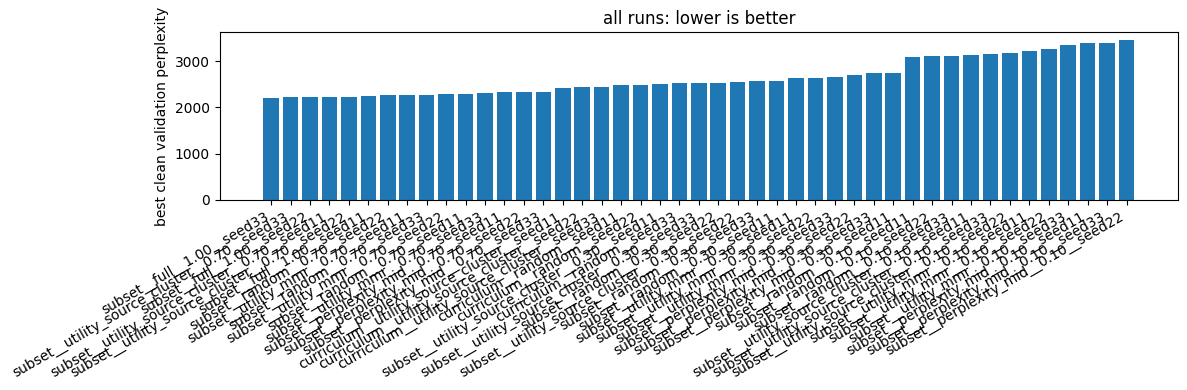

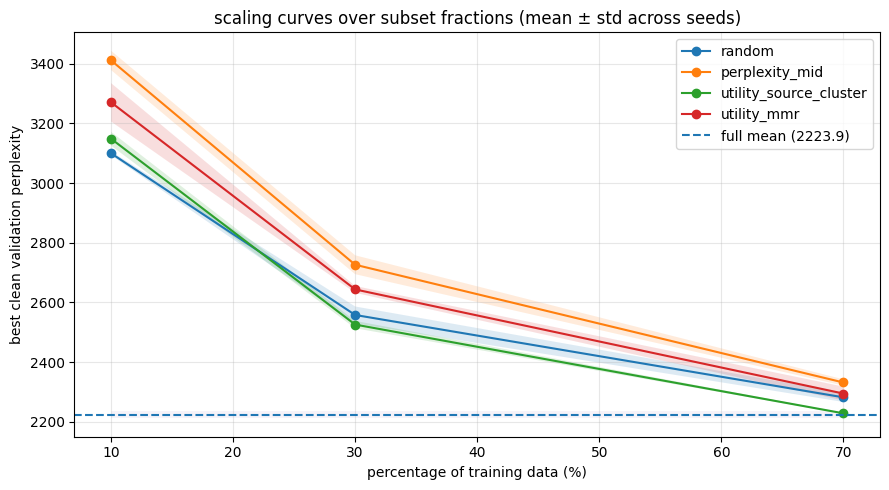

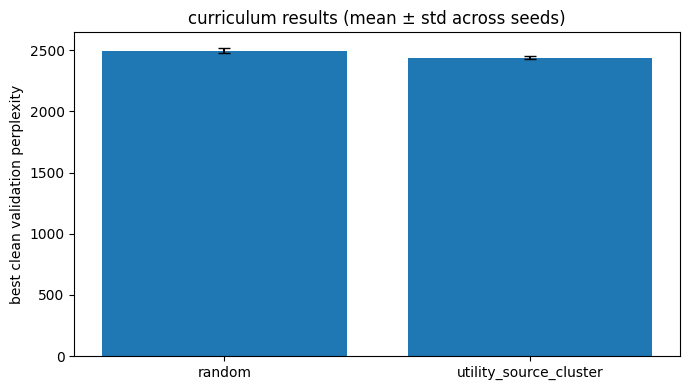

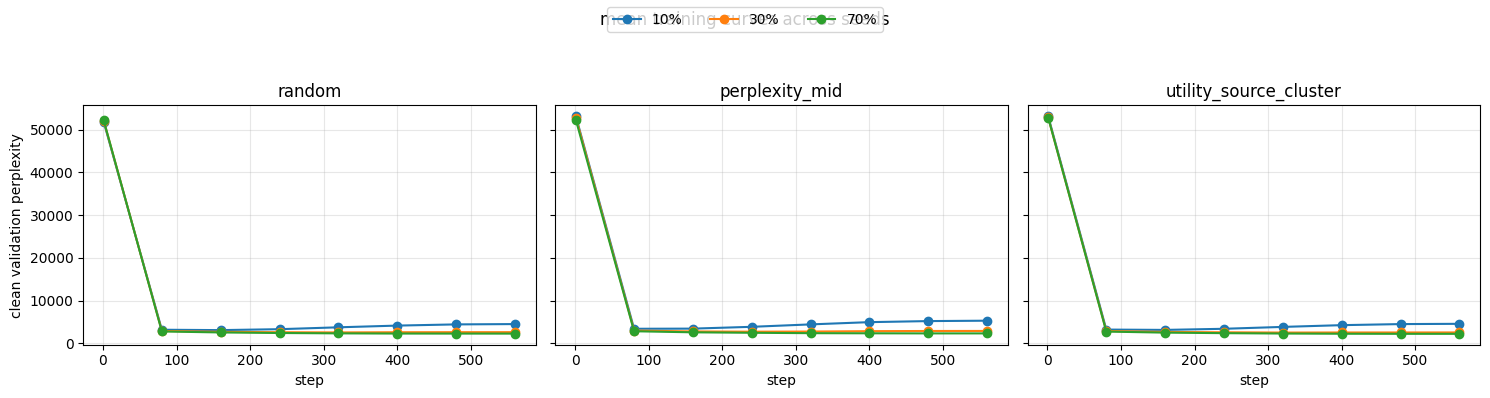

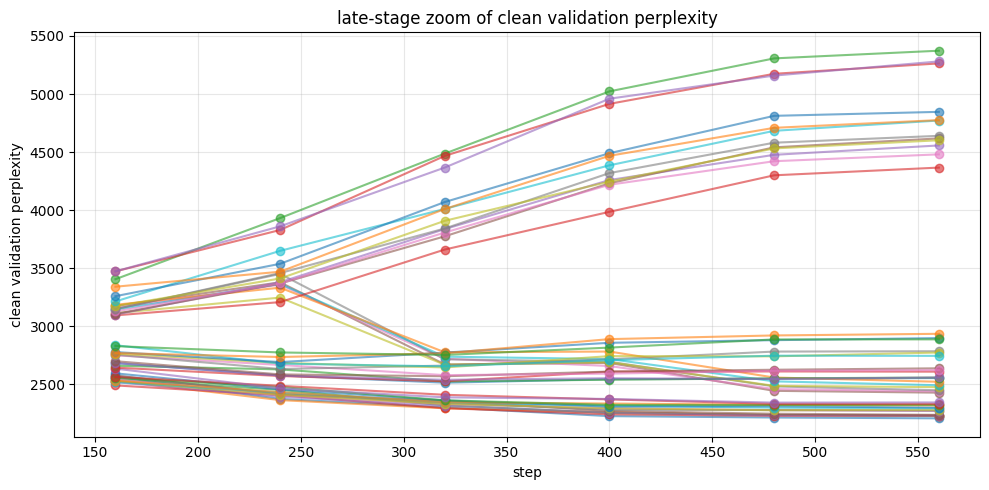

,mode,method,fraction,mean_best_clean_val_ppl,std_best_clean_val_ppl,n_runs
13,curriculum,utility_source_cluster,1.0,2438.183849,10.289665,3
12,curriculum,random,1.0,2496.008886,23.421380,3
3,subset,random,0.1,3099.870991,6.431259,3
9,subset,utility_source_cluster,0.1,3148.782406,23.095229,3
6,subset,utility_mmr,0.1,3270.785985,64.344910,3
0,subset,perplexity_mid,0.1,3411.420945,32.349676,3
10,subset,utility_source_cluster,0.3,2525.602786,12.428308,3
4,subset,random,0.3,2557.795241,28.461747,3
7,subset,utility_mmr,0.3,2643.465935,11.448852,3
1,subset,perplexity_mid,0.3,2726.230742,31.636704,3


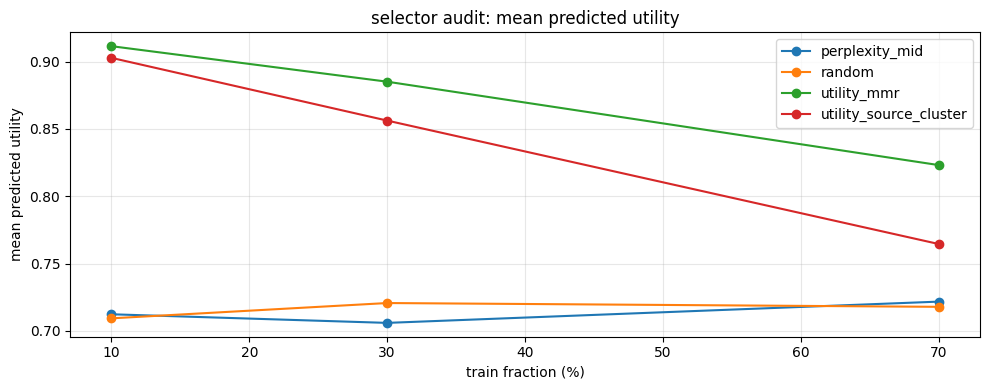

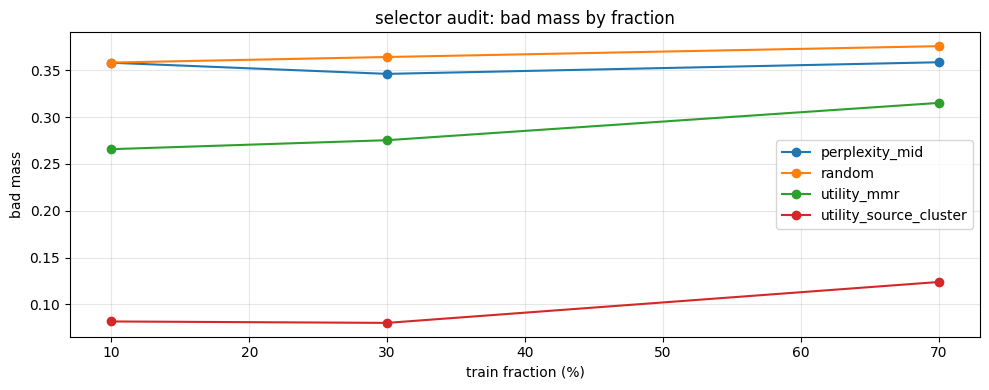

In [20]:

# ===== 17. plots =====
def mean_std_frame(df, value_col, group_cols):
    agg = df.groupby(group_cols)[value_col].agg(["mean", "std", "count"]).reset_index()
    agg["std"] = agg["std"].fillna(0.0)
    return agg

if len(all_summaries_disk) > 0:
    plot_df = all_summaries_disk.copy()
    plot_df["fraction_pct"] = (plot_df["fraction"].astype(float) * 100.0).round().astype(int)
    plot_df["label"] = plot_df.apply(
        lambda r: f"{r['mode']}__{r['method']}__{r['fraction']:.2f}" if r["mode"] == "subset" else f"{r['mode']}__{r['method']}",
        axis=1,
    )

    plot_df.to_csv(BASE_OUT_DIR / "all_summaries_with_labels.csv", index=False)
    display(plot_df.sort_values("best_clean_val_ppl").head(20))

    # per-run ranking
    plt.figure(figsize=(12, 4))
    order = plot_df.sort_values("best_clean_val_ppl")["label"] + "__seed" + plot_df.sort_values("best_clean_val_ppl")["seed"].astype(str)
    vals = plot_df.sort_values("best_clean_val_ppl")["best_clean_val_ppl"].values
    plt.bar(range(len(vals)), vals)
    plt.xticks(range(len(vals)), order, rotation=30, ha="right")
    plt.ylabel("best clean validation perplexity")
    plt.title("all runs: lower is better")
    plt.tight_layout()
    plt.savefig(BASE_OUT_DIR / "plots" / "all_runs_clean_results.png", dpi=160)
    plt.show()

    # aggregate subset scaling curves
    subset_df = plot_df[plot_df["mode"] == "subset"].copy()
    subset_df = subset_df[subset_df["method"] != "full"].copy()
    subset_agg = mean_std_frame(subset_df, "best_clean_val_ppl", ["method", "fraction"])
    subset_agg.to_csv(BASE_OUT_DIR / "subset_scaling_summary.csv", index=False)
    plt.figure(figsize=(9, 5))
    method_order = ["random", "perplexity_mid", "utility_source_cluster", "utility_mmr", "verified_source_cluster"]
    for method in method_order:
        sub = subset_agg[subset_agg["method"] == method].sort_values("fraction")
        if len(sub) == 0:
            continue
        x = sub["fraction"].values * 100.0
        y = sub["mean"].values
        e = sub["std"].values
        plt.plot(x, y, marker="o", label=method)
        plt.fill_between(x, y - e, y + e, alpha=0.15)
    if (plot_df["method"] == "full").any():
        full_rows = plot_df[plot_df["method"] == "full"]
        full_mean = float(full_rows["best_clean_val_ppl"].mean())
        full_std = float(full_rows["best_clean_val_ppl"].std(ddof=0))
        plt.axhline(full_mean, linestyle="--", label=f"full mean ({full_mean:.1f})")
        if full_std > 0:
            plt.fill_between([min(SUBSET_FRACTIONS)*100.0, 70.0], full_mean-full_std, full_mean+full_std, alpha=0.08)
    plt.xlabel("percentage of training data (%)")
    plt.ylabel("best clean validation perplexity")
    plt.title("scaling curves over subset fractions (mean ± std across seeds)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(BASE_OUT_DIR / "plots" / "scaling_curves_subset_mean_std.png", dpi=160)
    plt.show()

    # curriculum comparison
    curr_df = plot_df[plot_df["mode"] == "curriculum"].copy()
    if len(curr_df) > 0:
        curr_agg = mean_std_frame(curr_df, "best_clean_val_ppl", ["method"])
        curr_agg.to_csv(BASE_OUT_DIR / "curriculum_summary.csv", index=False)
        plt.figure(figsize=(7, 4))
        plt.bar(curr_agg["method"], curr_agg["mean"], yerr=curr_agg["std"], capsize=4)
        plt.ylabel("best clean validation perplexity")
        plt.title("curriculum results (mean ± std across seeds)")
        plt.tight_layout()
        plt.savefig(BASE_OUT_DIR / "plots" / "curriculum_summary.png", dpi=160)
        plt.show()

    # zoomed late-stage training curves averaged over seeds
    subset_methods_for_curves = ["random", "perplexity_mid", "utility_source_cluster"]
    curve_fig, axes = plt.subplots(1, len(subset_methods_for_curves), figsize=(5 * len(subset_methods_for_curves), 4), sharey=True)
    if len(subset_methods_for_curves) == 1:
        axes = [axes]
    for ax, method in zip(axes, subset_methods_for_curves):
        for frac in list(SUBSET_FRACTIONS) + [1.0]:
            if frac == 1.0 and method != "full":
                continue
            rows = plot_df[(plot_df["mode"] == "subset") & (plot_df["method"] == (method if frac < 1.0 else "full"))]
            if frac < 1.0:
                rows = rows[rows["fraction"].round(2) == round(float(frac), 2)]
            metrics_list = []
            for _, row in rows.iterrows():
                metrics_path = BASE_OUT_DIR / "experiments" / row["exp_name"] / "metrics.csv"
                if metrics_path.exists():
                    met = pd.read_csv(metrics_path)
                    if len(met) > 0:
                        metrics_list.append(met[["step", "clean_val_ppl"]].copy())
            if len(metrics_list) == 0:
                continue
            merged = None
            for j, met in enumerate(metrics_list):
                met = met.rename(columns={"clean_val_ppl": f"run{j}"})
                if merged is None:
                    merged = met
                else:
                    merged = merged.merge(met, on="step", how="outer")
            merged = merged.sort_values("step").ffill().bfill()
            y = merged.drop(columns=["step"]).mean(axis=1)
            ax.plot(merged["step"], y, marker="o", label=f"{int(round(frac*100))}%")
        ax.set_title(method)
        ax.set_xlabel("step")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("clean validation perplexity")
    handles, labels = axes[-1].get_legend_handles_labels()
    if len(handles) > 0:
        curve_fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)))
    curve_fig.suptitle("mean training curves across seeds")
    curve_fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig(BASE_OUT_DIR / "plots" / "mean_training_curves_by_method.png", dpi=160)
    plt.show()

    # late-stage zoom only
    plt.figure(figsize=(10, 5))
    for _, row in plot_df.iterrows():
        metrics_path = BASE_OUT_DIR / "experiments" / row["exp_name"] / "metrics.csv"
        if not metrics_path.exists():
            continue
        met = pd.read_csv(metrics_path)
        if len(met) == 0:
            continue
        met = met[met["step"] >= max(cfg.eval_every, int(cfg.max_steps * 0.25))].copy()
        if len(met) == 0:
            continue
        label = row["label"] + "__seed" + str(row["seed"])
        plt.plot(met["step"], met["clean_val_ppl"], marker="o", alpha=0.6, label=label)
    plt.xlabel("step")
    plt.ylabel("clean validation perplexity")
    plt.title("late-stage zoom of clean validation perplexity")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(BASE_OUT_DIR / "plots" / "training_curves_clean_late_zoom.png", dpi=160)
    plt.show()

    # compact summary table
    report_rows = []
    if len(subset_df) > 0:
        agg = mean_std_frame(subset_df, "best_clean_val_ppl", ["method", "fraction"])
        for _, r in agg.iterrows():
            report_rows.append({
                "mode": "subset",
                "method": r["method"],
                "fraction": float(r["fraction"]),
                "mean_best_clean_val_ppl": float(r["mean"]),
                "std_best_clean_val_ppl": float(r["std"]),
                "n_runs": int(r["count"]),
            })
    if len(curr_df) > 0:
        agg = mean_std_frame(curr_df, "best_clean_val_ppl", ["method"])
        for _, r in agg.iterrows():
            report_rows.append({
                "mode": "curriculum",
                "method": r["method"],
                "fraction": 1.0,
                "mean_best_clean_val_ppl": float(r["mean"]),
                "std_best_clean_val_ppl": float(r["std"]),
                "n_runs": int(r["count"]),
            })
    if (plot_df["method"] == "full").any():
        full_rows = plot_df[plot_df["method"] == "full"]
        report_rows.append({
            "mode": "subset",
            "method": "full",
            "fraction": 1.0,
            "mean_best_clean_val_ppl": float(full_rows["best_clean_val_ppl"].mean()),
            "std_best_clean_val_ppl": float(full_rows["best_clean_val_ppl"].std(ddof=0)),
            "n_runs": int(len(full_rows)),
        })
    report_df = pd.DataFrame(report_rows)
    report_df.to_csv(BASE_OUT_DIR / "report_summary.csv", index=False)
    display(report_df.sort_values(["mode", "fraction", "mean_best_clean_val_ppl"]))

if (BASE_OUT_DIR / "selection_audit.csv").exists():
    audit_df_disk = pd.read_csv(BASE_OUT_DIR / "selection_audit.csv")
    audit_plot = audit_df_disk[audit_df_disk["method"] != "full"].copy()

    plt.figure(figsize=(10, 4))
    for method, grp in audit_plot.groupby("method"):
        grp = grp.sort_values("fraction")
        plt.plot(grp["fraction"] * 100.0, grp["mean_predicted_utility"], marker="o", label=method)
    plt.title("selector audit: mean predicted utility")
    plt.xlabel("train fraction (%)")
    plt.ylabel("mean predicted utility")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(BASE_OUT_DIR / "plots" / "selector_audit_mean_predicted_utility.png", dpi=160)
    plt.show()

    plt.figure(figsize=(10, 4))
    for method, grp in audit_plot.groupby("method"):
        grp = grp.sort_values("fraction")
        plt.plot(grp["fraction"] * 100.0, grp["bad_mass"], marker="o", label=method)
    plt.title("selector audit: bad mass by fraction")
    plt.xlabel("train fraction (%)")
    plt.ylabel("bad mass")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(BASE_OUT_DIR / "plots" / "selector_audit_bad_mass.png", dpi=160)
    plt.show()


## как интерпретировать

Главное смотреть в таком порядке:

1. `subset_scaling_summary.csv` и `scaling_curves_subset_mean_std.png`  
   Здесь основной вопрос: дает ли `utility_source_cluster` устойчивый выигрыш над `random` на 10%, 30%, 70%

2. `curriculum_summary.csv`  
   Здесь видно, сильнее ли utility-aware curriculum, чем curriculum random

3. `report_summary.csv`  
   Это компактная таблица mean ± std по seed'ам

4. `selection_audit.csv`  
   Здесь проверяется, что utility-selector действительно меняет состав subset'а, а не просто шумит

Если utility-method выигрывает только на одном fraction и не держится по seed'ам, это пока слабый результат  
Если он выигрывает стабильно на 30% и не разваливается на 70%, это уже хороший аргумент в пользу usefulness-based filtering
